In [508]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
import random 
import json
import pandas as pd
from ast import literal_eval
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


#RMSE/MAE analysis
# def time_reader(fname, core=4):
#     lines=open(fname).readlines()
#     start_iter=0
#     end_iter = 0
#     counter=0
#     str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     start_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
#     str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     end_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     return (core_times, start_iter, end_iter)

def time_reader(fname, core=4):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    # core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
    core_times=[]
    all_times = []
    for i in lines[1*core:1*core+core]:
        num_list = ' '.join(i.strip().split(" ")[2:])
        # print(i)
        # print(num_list)
        num_list = ast.literal_eval(num_list)
        core_times.append(sum(num_list))
        all_times.extend(num_list)
    #core_times = [ sum(ast.literal_eval(i.strip().split(" ")[-1])) for i in lines[1*core:1*core+core]]

    str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter, all_times)


def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 

def time_predictor(peak_times, fp, bg_load=0, t=38):
    # sorted(fp)

    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1 and bg_load==0:
        return achieved_fps
    elif len(peak_times)==1:
        val = tf_calc(len(peak_times)+bg_load, t)
        # print(val, bg_load)
        val = val if val < 0.5 else 0.5
        gnt = (peak_times[0]-maybe_gnt[0])/(1-val)
        achieved_fps = [gnt]
        return achieved_fps

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y


def simulation_reader(fname):
    #assumed to be in order of arrival already
    df = pd.read_csv(fname)
    time_taken={}
    overhead={}
    bn={}
    bs={}
    world={}
    added_time={}
    ty={}
    for t_id in df['task_id']:
        j = t_id.split(".")[0]
        if j not in time_taken:
            time_taken[j]=0
            overhead[j]=0
            bn[j]=0
            bs[j]=0
            world[j]=0
            added_time[j]=0
            ty[j]='c'
        else:
            continue
        # print(df[df['task_id']==t_id]['clock'][-1:])
        # print(df[df['task_id']==t_id]['clock'].values[-1] )
        cor=1
        arr_t = df[df['task_id']==t_id]['clock'].values[-1]
        wait_t = df[df['task_id']==t_id]['task_wait'].values[-1]
        rem_t = df[df['task_id']==t_id]['task_remaining_time'].values[-1]
        # run_t = max(df[df['task_id']==t_id]['run_time'].values)*12
        run_t = max(df[df['task_id']==t_id]['run_time'].values)
        d_bn = df[df['task_id']==t_id]['bn'].values[-1] 
        d_bs = df[df['task_id']==t_id]['bs'].values[-1] 
        world[j]=df[df['task_id']==t_id]['world'].values[-1] 
        time_taken[j] =  (arr_t + run_t*cor + wait_t)#rem_t
        # time_taken[j] =  arr_t + rem_t#rem_t
        # time_taken[j] = df[df['task_id']==t_id]['clock'].values[-1] + df[df['task_id']==t_id]['run_time'].values[-1] 
        time_taken[j] = float(time_taken[j])
        ty[j]=df[df['task_id']==t_id]['type'].values[0]
        for d_ind, d in enumerate(df.iterrows()):
            # if d_ind==0:
            #     continue
            # print(d[1]["clock"])
            # print(d["clock"].values)
            d=d[1]
            overhead[j] = (overhead[j]+1) if d['clock']+d['task_wait']<=arr_t+wait_t<= d['clock']+d['task_wait']+d['run_time']*cor else (overhead[j]+0)
        bn[j] = d_bn
        bs[j] = d_bs
        added_time[j]=arr_t+wait_t
    return time_taken, overhead, bs, bn, world, added_time, ty


def best_fit_reader(fname, subcluster, model, world, bg, bs, bn, bw=240, ty='c', col_flag="mean"):
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    # df = df[ df["subcluster"]==subcluster ]
    ranks_to_time_slice = {r:[0]*r+[1]*bn+[0]*(world-r-1) for r in range(world)}
    time_to_ranks_slice = {}
    for s in range(len(ranks_to_time_slice[0])):
        if s not in time_to_ranks_slice:
            time_to_ranks_slice[s]=[]
        for r in ranks_to_time_slice:
            if ranks_to_time_slice[r][s]!=0:
                time_to_ranks_slice[s].append(r)
    
    mean_rt=0
    pred_rt=0
    naive_pred=0
    std_val=np.inf
    # std_val=0
    # bw=240 #mbps
    # print(len(time_to_ranks_slice), world, bg, )
    for s in time_to_ranks_slice:
        slice_arr=[0]
        pred_slice_arr=[0]
        std_arr=[]
        nw_arr=[0]
        # bg= (bg+len(time_to_ranks_slice[s])) if len(time_to_ranks_slice[s])>1 else bg
        overhead = len(time_to_ranks_slice[s]) - 1 + bg
        # print(overhead)
            # overhead = bg+overhead+min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # if overhead not in set(vit_df[vit_df["world"]==world]["bg_load"].values):
            #     overhead = bg+overhead-min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # print(set(vit_df[vit_df["world"]==world]["bg_load"].values))
            # print(min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)]), bg, overhead)
            # overhead+=min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])

        for r in time_to_ranks_slice[s]:
            # temp_pred = (time_predictor([flop/2.8], [flop], overhead, t=map_sub["bramble-1-3"])[0])
            
            if overhead not in set(df[ (df["rank"]==r) & (df["type"]==ty) ]["bg_load"].values):
                l = [i for i in set(df[(df["rank"]==r) & (df["type"]==ty) ]["bg_load"].values)] + [overhead]
                l = sorted(l)

                # if bg==2:
                # print(l, overhead-bg, bg, overhead)
                for l_ind, t in enumerate(l):
                    if t==overhead:
                        # if l_ind+1 < len(l)-1:
                        #     overhead=l[l_ind+1]
                        # else:
                            overhead=l[l_ind-1]
                
            if len(df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values)>0:
                rt = df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                # print(rt)
                # slice_arr.append(np.mean(rt))
                slice_arr.append(np.max(rt))
                std_arr.extend( [i**2 for i in df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"std_dev"].values])
                flop = df[(df["world"]==world) & (df["bg_load"]==overhead) & (df["rank"]==r) ]["flops"].values[0]
                # temp_pred = (time_predictor([flop/fp_rate[model if model=="resnet18" else f"{model}_{ty}"]], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop/fp_rate[model]], [flop], overhead, t=map_sub[subcluster])[0])
                full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                
                #what would a naiive time predictor look like?
                #just model time -> is this just the matrix multiply? or is this more about not considering the floips? 
                temp_pred = (time_predictor([np.min(full_rt) if model!="resnet18" else np.min(full_rt)*1.5], [flop], overhead, t=map_sub[subcluster])[0])
                pred_slice_arr.append(temp_pred)
                # pred_slice_arr.append(temp_pred)
                # flop = df[ (df["bg_load"]==overhead) & (df["rank"]==r) ]["flops"].values[0]
                nw = df[(df["bg_load"]==overhead) & (df["rank"]==r)  & (df["type"]==ty)]["nw_size"].values[0]
                if r!=world-1:
                    nw_arr.append(nw*8/bw)


        mean_rt+=np.max(slice_arr) + np.max(nw_arr)
        pred_rt+=np.max(pred_slice_arr) + np.max(nw_arr)
        naive_pred+=np.max(nw_arr)
        std_val=np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        # std_val=np.mean(std_arr) if std_val < np.mean(std_arr) else std_val
    # print(time_to_ranks_slice)
    # print(mean_rt)
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    for r in range(world):
        # print(r, world)
        full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
        if len(full_rt)==0:
            continue
        # print(df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"])
        flop = df[(df["rank"]==r) & (df["type"]==ty) ]["flops"].values[0]
        naive_pred += (time_predictor([np.min(full_rt)*bn], [flop], bg+world-1, t=map_sub[subcluster])[0])
    # naive_pred*=bs
    return round(mean_rt*bs,3), std_val, round(pred_rt*bs,3), round(naive_pred*bs, 3)

# fp_rate = {"resnet18": 12, "vit": 12, "vit_c":12, "vit_nw":5 , "eff":2.2, "eff_c":2, "eff_nw":2}
# fp_rate = {"resnet18": 20, "vit": 20, "eff":3}
fp_rate = {"resnet18": 14.4, "vit": 16.4, "eff":3}
# fp_rate = {"resnet18": 25, "vit": 25, "eff":6}

map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }



6 rmse old_train: 3.1358240078383517
6 mae old_train: 3.0629819473968043
5 rmse old_train: 4.944909380246194
5 mae old_train: 4.922384181449651
4 rmse old_train: 4.854172206846205
4 mae old_train: 4.75089584459606
3 rmse old_train: 5.688994859112369
3 mae old_train: 5.6496990479195786
6 rmse old_train: 0.27068053658607066
6 mae old_train: 0.26468569059635055
5 rmse old_train: 0.2611318154808764
5 mae old_train: 0.2507196840216389
4 rmse old_train: 0.2014640094153531
4 mae old_train: 0.18439263983323204
3 rmse old_train: 0.19653961509268708
3 mae old_train: 0.16641445302726018
6 rmse old_train: 0.11658404541702132
6 mae old_train: 0.11485816208777486
5 rmse old_train: 0.1524701983593248
5 mae old_train: 0.14717794506758114
4 rmse old_train: 0.3527065043009116
4 mae old_train: 0.3509956152084178
3 rmse old_train: 0.7449552817056913
3 mae old_train: 0.7439812273143017
6 rmse old_train: 2.5673208563869063
6 mae old_train: 2.537023184979705
5 rmse old_train: 4.657162209204373
5 mae old_trai

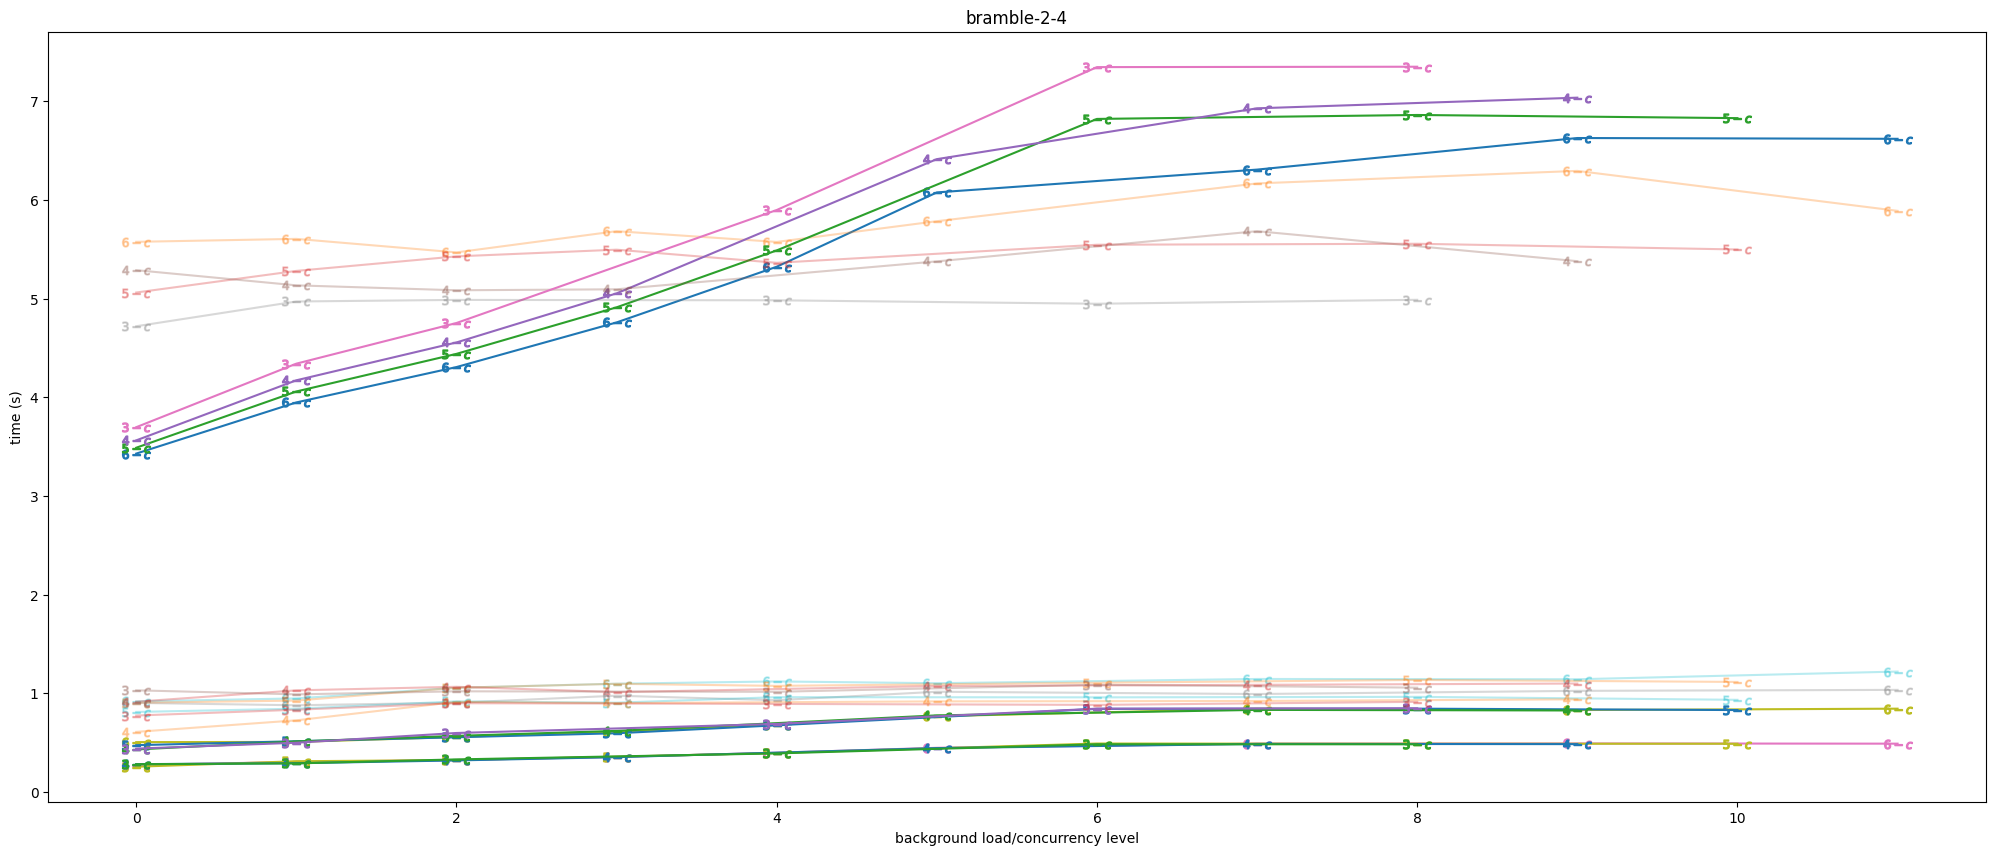

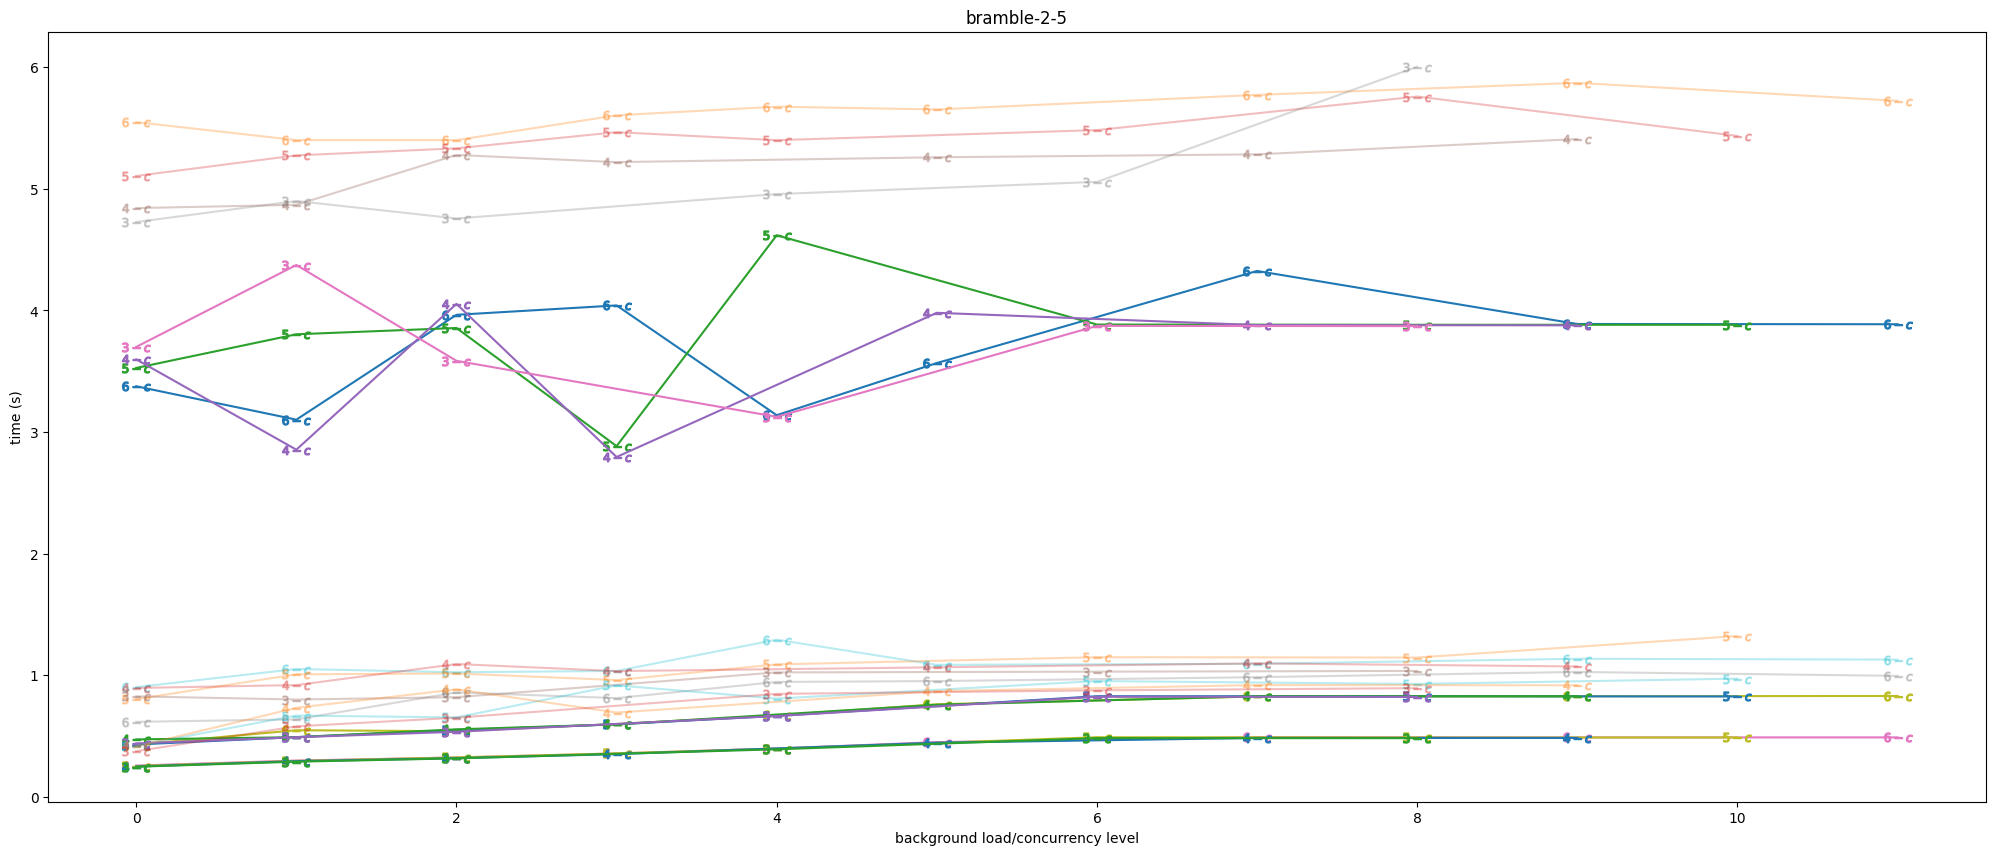

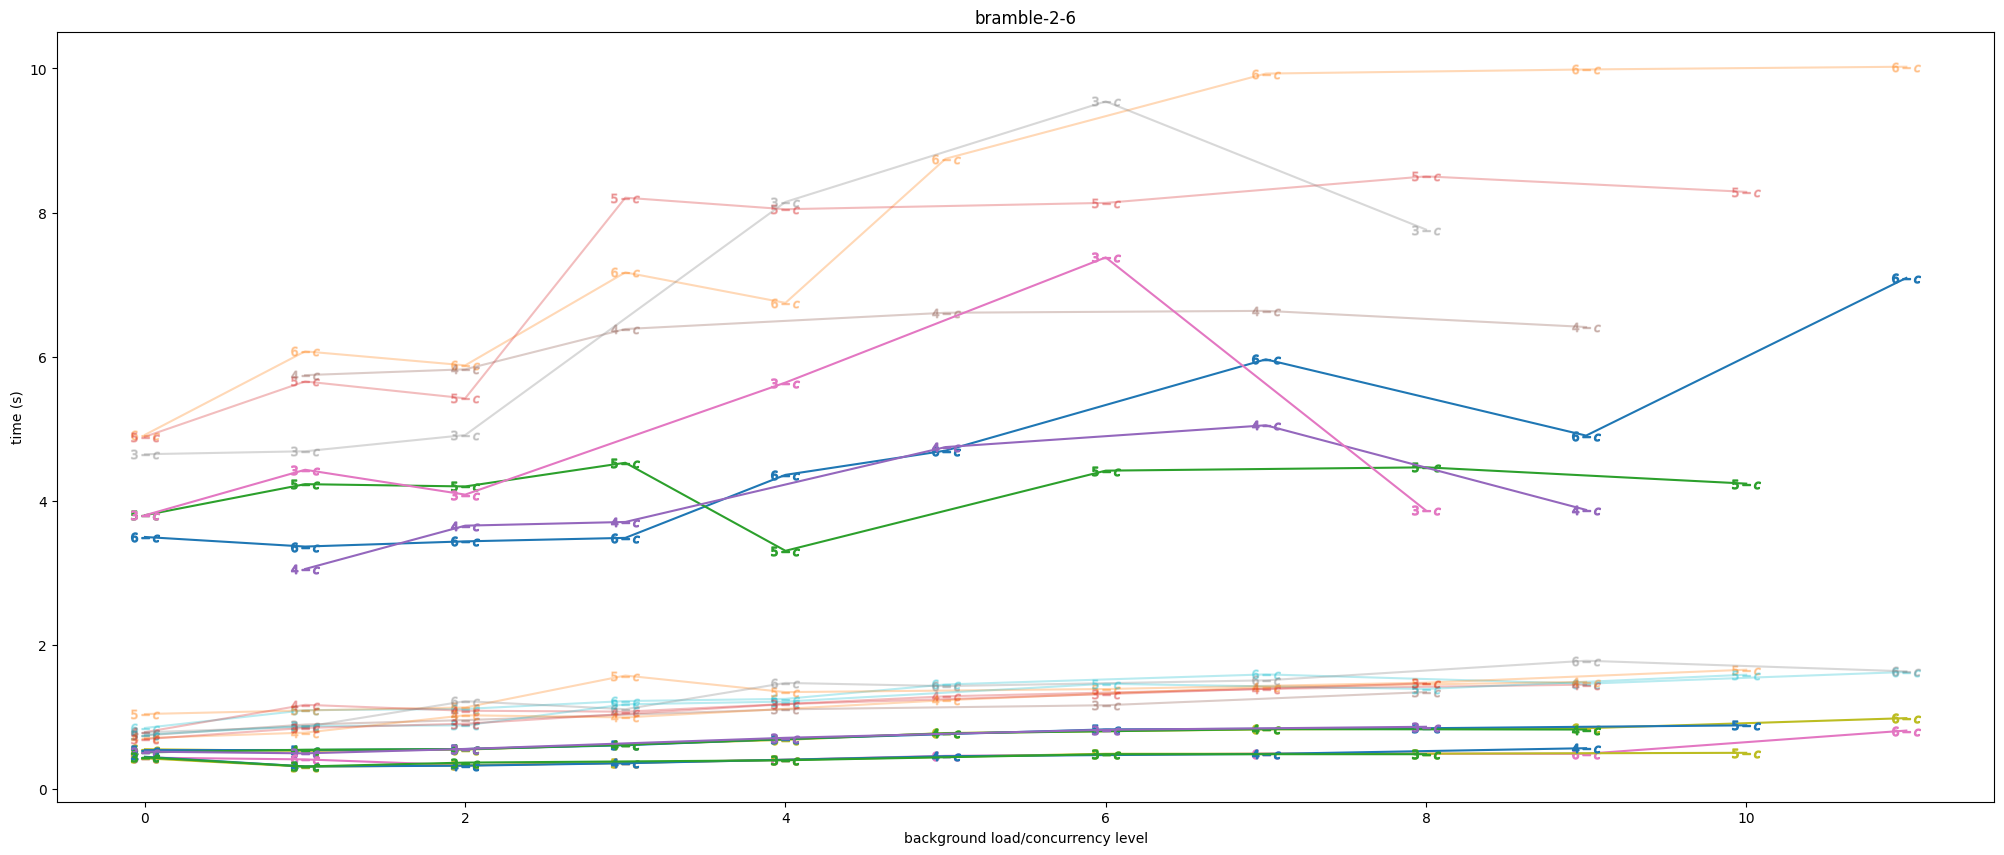

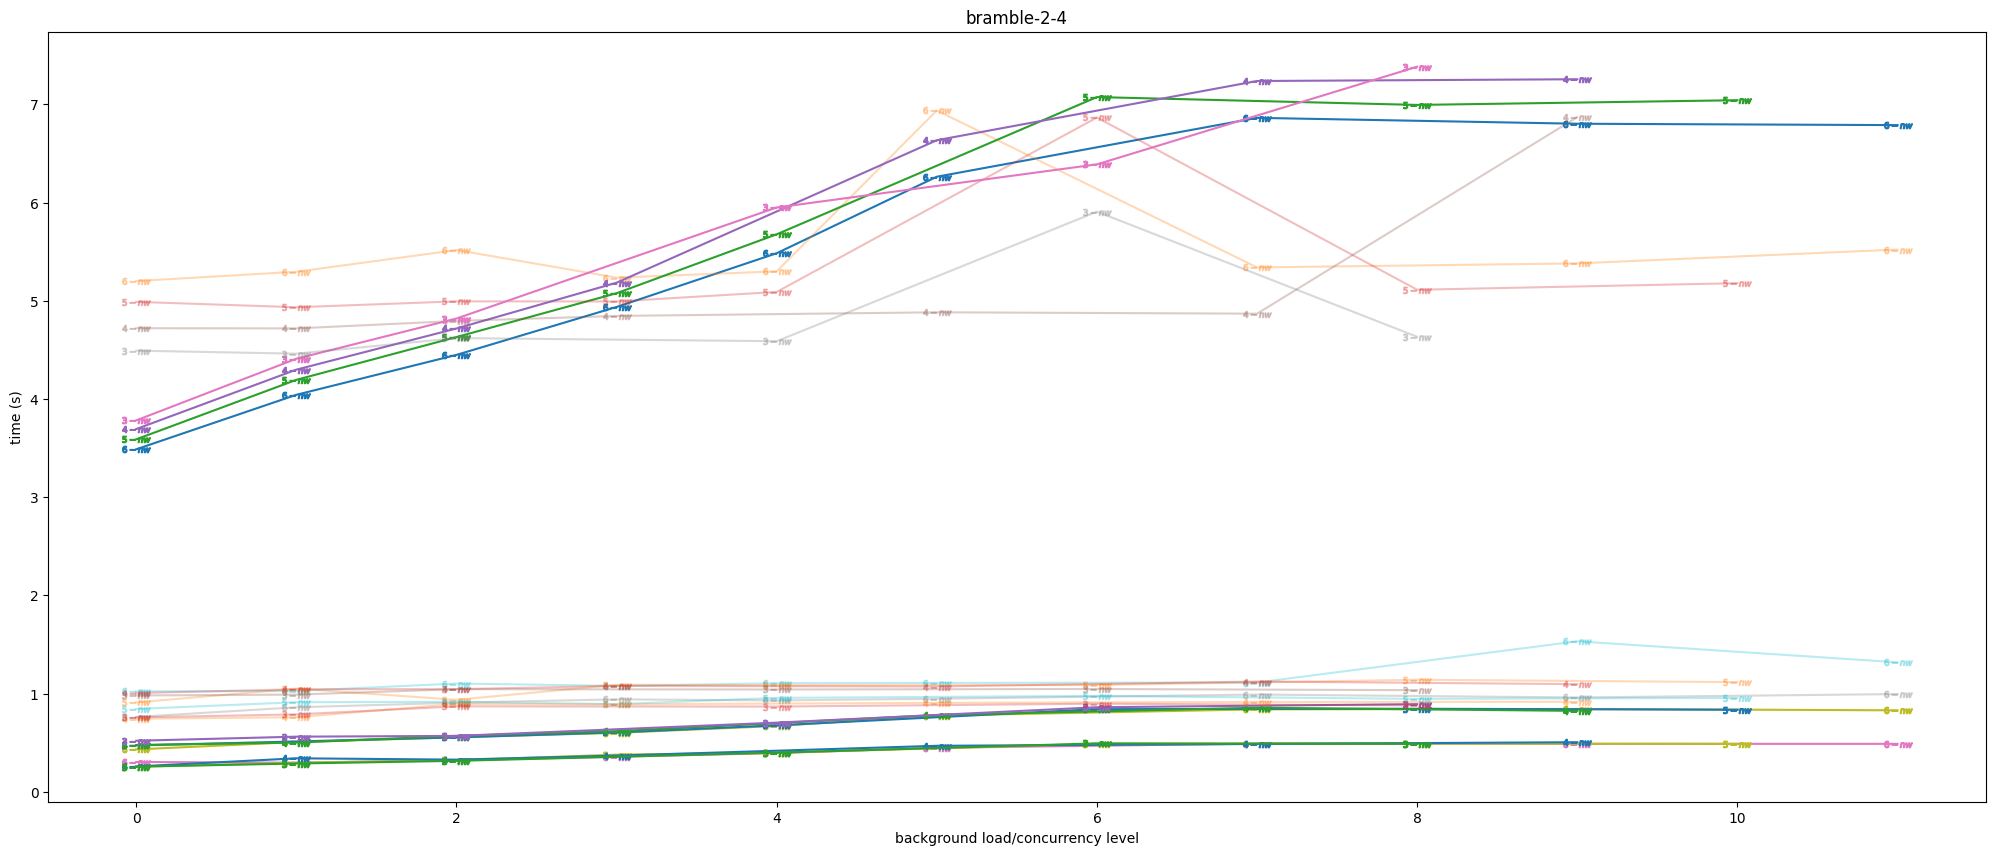

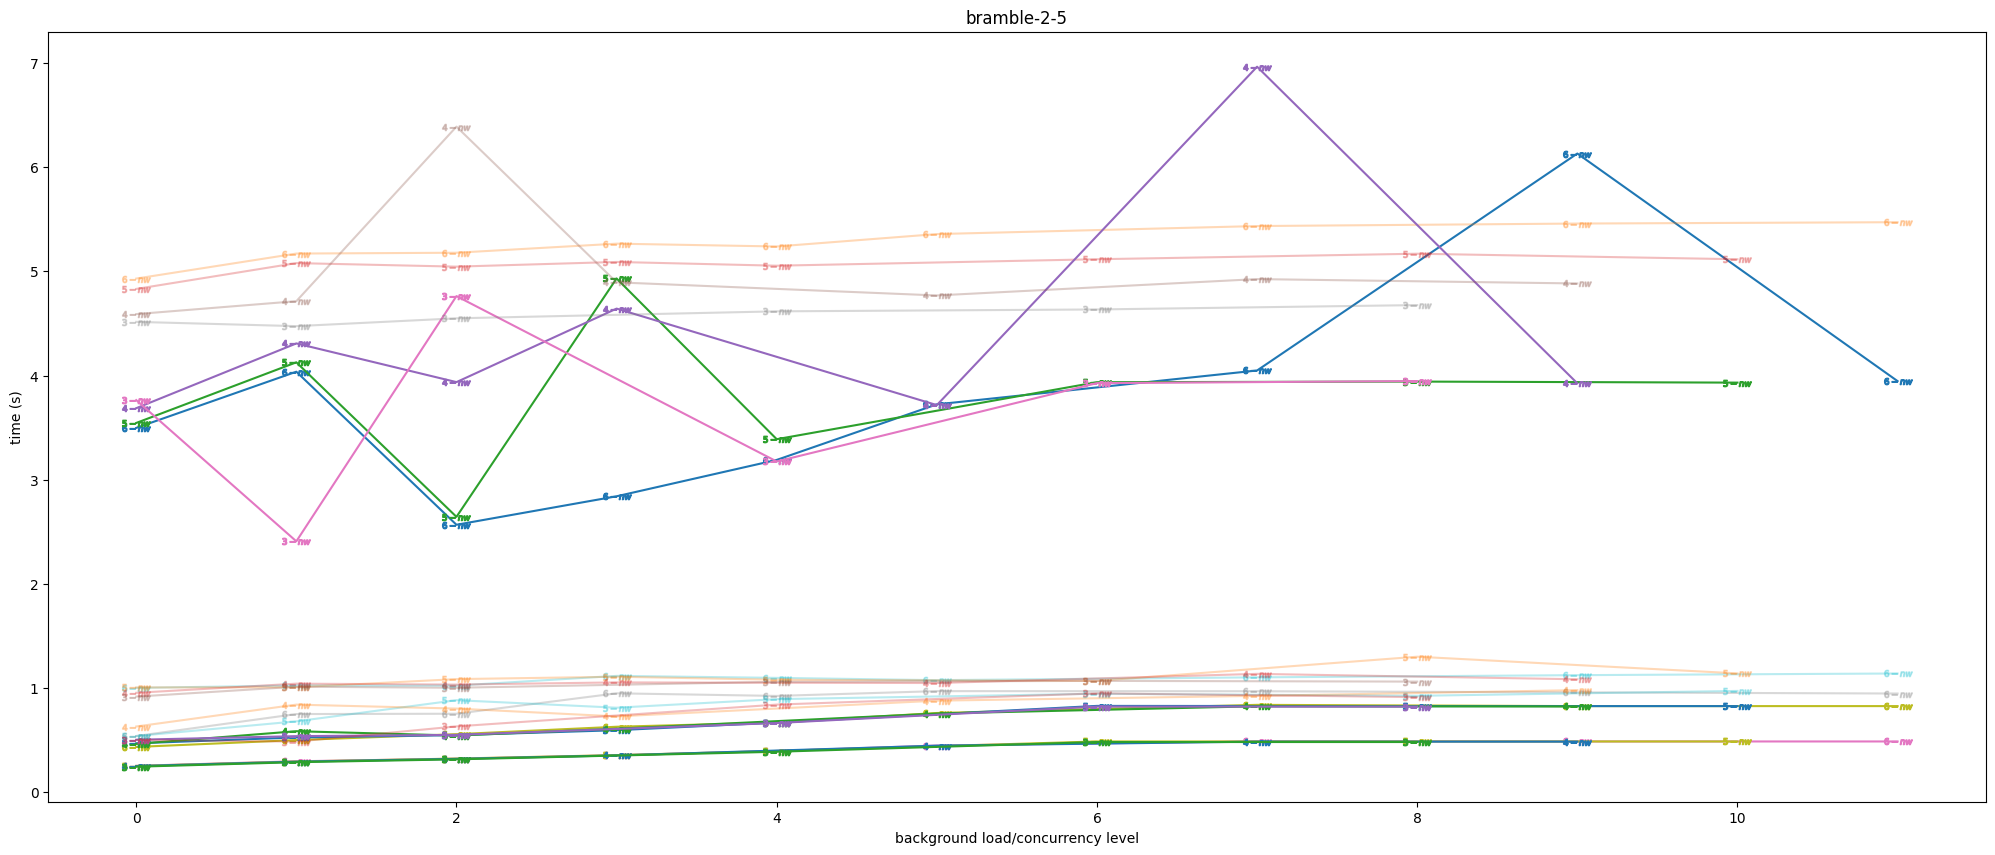

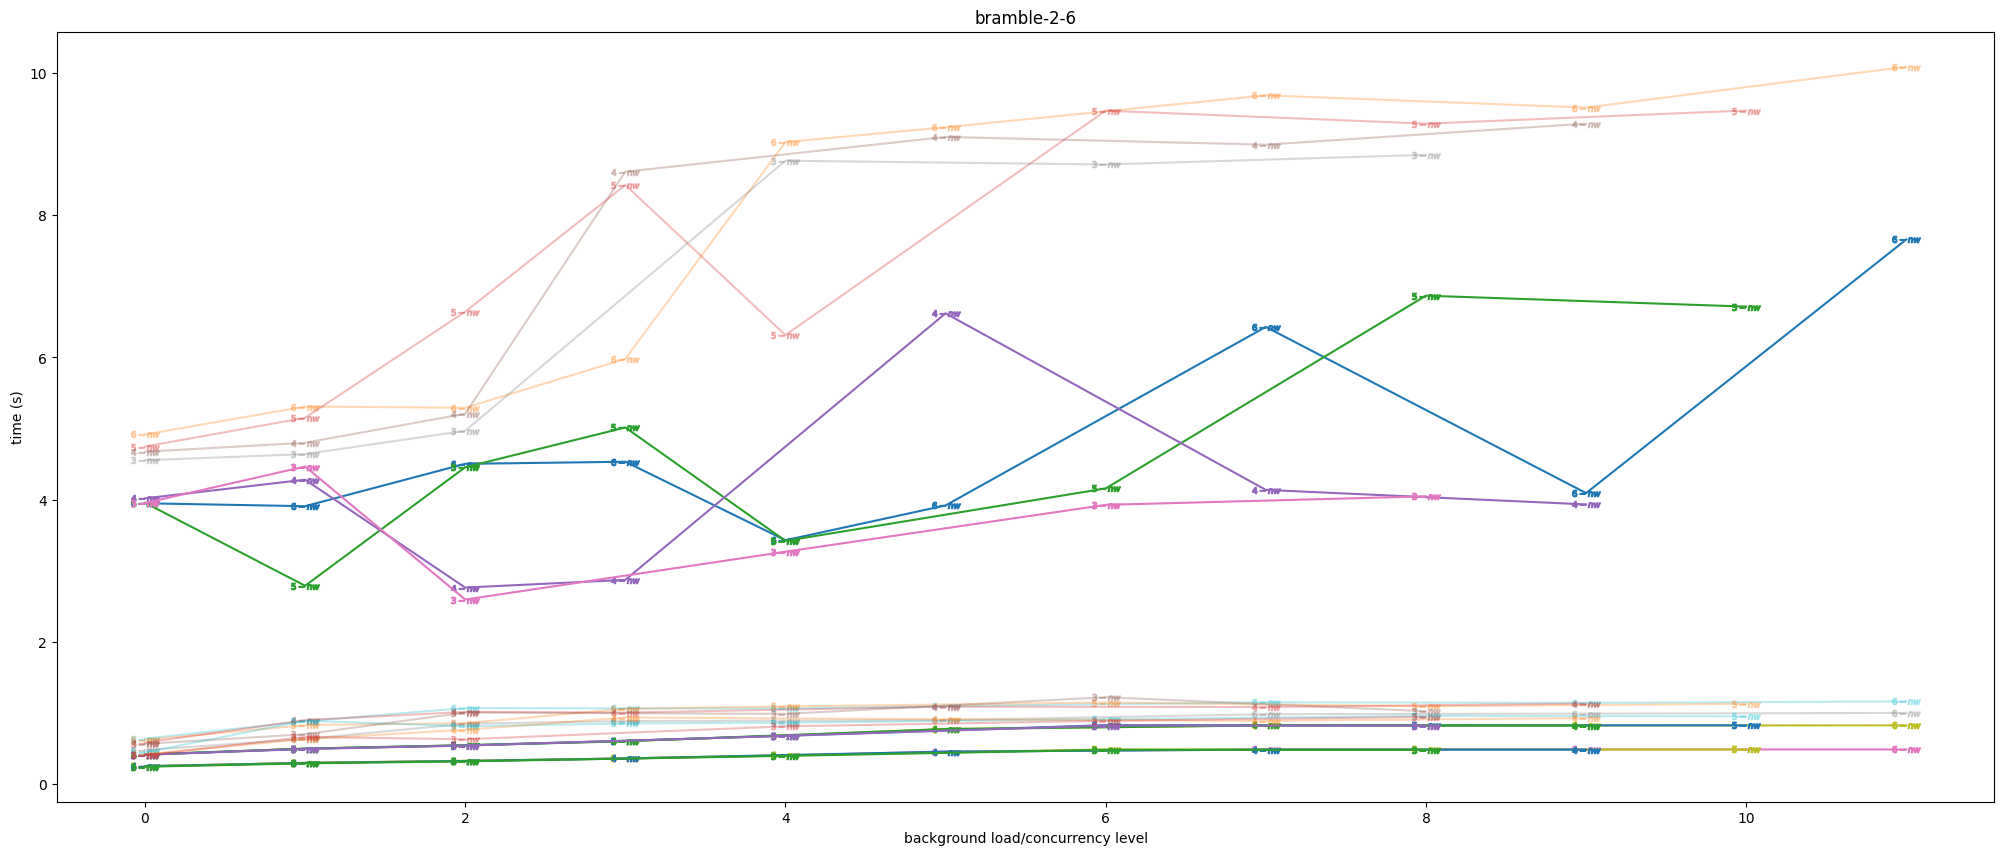

In [452]:
#for the hardcoded case 
# /Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/bramble-4-2/tcn_splits_onnx/0/0/speed_chronosbramble-4-2-12_5_0_1.log
import json
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# prefix_path = "/Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/"
prefix_path = "/Users/animeshnd/model_splitting/logs/pipeline_exploration/"
subclusters=[
    "bramble-1-3","bramble-2-1",
    "bramble-2-2","bramble-2-5","bramble-2-6",
    "bramble-4-1","bramble-4-2","bramble-4-3","bramble-4-5", "bramble-4-6",
    ]
# subclusters=[
#     "bramble-2-5","bramble-2-6",
#     "bramble-4-1","bramble-4-2",
#     ]
map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }

global_y=[]
global_x=[]
global_pred_y = []

# for p in subclusters:
#subclusters that work: bramble-1-3, bramble-2-5, bramble-2-6, bramble-4-1?, bramble-4-2?, bramble-4-3?, 
worlds = [6,5,4,3]
# fig, m_axs = plt.subplots(len(worlds), figsize=(25,40) )
# fig, axs = plt.subplots(figsize=(25,10) )
peak_bw=270
bs=1
csv_header = "model,world,rank,bg_load,max_runtime,mean_runtime,median_runtime,std_dev,nw_size,flops,subcluster,type\n"
csv_lines = [csv_header]
# for tr in [1,2]:
for tr in ['c', 'nw']:
    # if tr > 1:
    #     contin
    # for p in ["bramble-2-5"]:
    # for p in subclusters:
    for p in ["bramble-2-4", "bramble-2-5", "bramble-2-6"]:
        fig, axs = plt.subplots(figsize=(25,10) )
        axs.set_title(f"{p}")
        sub_path = f"{prefix_path}/{p}"
        if Path(sub_path).is_dir()==False:
            continue
        for model_splits in Path(sub_path).iterdir():
            model = str(model_splits).split("/")[-1].split("_")[0]
            if model=="tcn":
            # if model!="resnet18":
            # if model!="eff":
            # if model!="vit":
                continue
            # if model!="vit":
            #     continue
            # for iter in model_splits.iterdir():
            #     iter_id = int(str(iter).split("/")[-1])

            for w_ind, world in enumerate(worlds):
            # for world in [3]:
                # fig, axs = plt.subplots(figsize=(25,10))
                # axs = m_axs[w_ind]
                world_map={r:{} for r in range(world)}
                for rank in range(world):
                    for iter in model_splits.iterdir():
                        iter_id = int(str(iter).split("/")[-1])
                        # print(iter_id)
                        #we know it's hardcoded to 4-2-12 so only check for 4-2-12
                        #iter id says number of interferences
                        for repeat in ['']:#range(0,11):
                            # for split in range(0,2):
                            #if 1 == comp split
                            #if 0 == nw split
                            for d in range(1,43):

                                only_blue_file = open(f"./{p}.just_blue_res.op")
                                only_red_blue_file = open(f"./{p}.red_blue.op")
                                only_blue_devs = [i.strip() for i in only_blue_file.readlines()]
                                only_red_blue_devs = [i.strip() for i in only_red_blue_file.readlines()]
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-1-{d}_{world}_{rank}_1.log"
                                # fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_0.log"
                                fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_{tr}.log"
                                # if f"{p}-{d}" not in only_blue_devs:
                                # if f"{p}-{d}" in only_red_blue_devs:
                                #     continue
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-2-{d}_{world}_{rank}_1.log"
                                # flop = open(f"../experiments/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = open(f"../scheduler/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = json.load(flop)
                                nw = [r["boundary_transfer_bytes"]*bs*10**-6 for r in flop["splits"]]
                                flop = [r["actual_flops"]*bs*10**-9 for r in flop["splits"]]

                                if Path(fname).is_file()==False:
                                    continue
                                # print(fname)
                                # core_times, _, _, all_times = time_reader(fname, core=1)
                                try:
                                    core_times, _, _, all_times = time_reader(fname, core=1)
                                    # print(core_times)
                                except Exception as e:
                                    # print(e)
                                    continue
                                if 0 in all_times:
                                    continue
                                if iter_id not in world_map[rank]:
                                    world_map[rank][iter_id] = []
                                # world_map[rank][iter_id].extend([flop[rank]/i for i in all_times[1:]])
                                # world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(float(np.median(all_times)))
                                world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(all_times[1:])
                                # print(all_times)
                trial_len = len(list(world_map[0].keys()))
                # print(list(world_map[0].keys()))
                summary_y = [0]*trial_len
                summary_min_y = [0]*trial_len
                summary_max_y = [0]*trial_len
                summary_pred_y = [0]*trial_len
                summary_min_pred_y = [0]*trial_len
                error_y=[0]*trial_len
                for r in range(world):
                # for r in [0, world-1]:
                    x = sorted(list(world_map[r].keys()))
                    # print(world_map[r])
                    # y = [np.median(world_map[r][k]) for k in x]
                    
                    # y = [np.min(world_map[r][k])*bs if k<=2 else np.max(world_map[r][k]) for k in x]
                    y = [np.max(world_map[r][k])*bs for k in x]
                    # print(y)
                    if len(y)!=trial_len:
                        continue
                    min_y = [np.min(world_map[r][k])*bs for k in x]
                    max_y = [np.max(world_map[r][k])*bs for k in x]
                    # y = [np.min(world_map[r][k]) for k in x]
                    # y = [np.max(world_map[r][k]) for k in x]
                    # print(world_map[r])
                    # y = [world_map[r][k] for k in x]
                    pred_y = []
                    # print([np.mean(world_map[r][k]) for k in x])
                    for k in x:
                        pred_time = time_predictor( [np.min(world_map[r][k])], [flop[r]], bg_load=k, t=map_sub[p])
                        # world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster
                        # temp_line = f"{model},{world},{r},{k},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        temp_line = f"{model},{world},{r},{k},{np.max(world_map[r][k])},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        csv_lines.append(temp_line)
                        # pred_time = time_predictor( [ (flop[r])/3], [flop[r]], bg_load=k, t=map_sub[p]) #for resnet
                        # pred_time = time_predictor( [ (flop[r])/0.2], [flop[r]], bg_load=k, t=map_sub[p]) #for efficient net
                        pred_y.append(pred_time[0])
                    # print(y)
                    summary_max_y = [summary_max_y[i]+max_y[i] for i in range(trial_len)]
                    # summary_min_y = [summary_min_y[i]+min_y[i] for i in range(trial_len)]
                    # summary_min_y = [ (summary_min_y[i]+min_y[i]+nw[r]*1/peak_bw if flop[r]==max(flop) else summary_min_y[i]+y[i]+nw[r]*1/peak_bw ) for i in range(trial_len)]
                    summary_min_y = [ summary_min_y[i]+nw[r]*1/peak_bw + (min_y[i] if flop[r]==max(flop) else y[i]) for i in range(trial_len)]
                    # summary_y = [summary_y[i]+y[i] for i in range(trial_len)]
                    summary_y = [summary_y[i]+y[i]+nw[r]*1/peak_bw for i in range(trial_len)]
                    # print(world_map[r][0])
                    # error_y = [error_y[i]+np.var([ 10/j for j in world_map[r][x[i]]]) for i in range(trial_len)]
                    # print(error_y)
                    # summary_pred_y = [summary_pred_y[i]+( pred_y[i] if flop[r] in sorted(flop, reverse=True)[:1] else min_y[i]) for i in range(trial_len)]
                    summary_pred_y = [summary_pred_y[i]+( pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( pred_y[i] if flop[r]==max(flop) else flop[r]/1.5) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/0.2 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/3 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]

                    # y = [flop[r]/i for i in y]
                    # max_y = [flop[r]/i for i in max_y]
                    # min_y = [flop[r]/i for i in min_y]
                    # # axs.fill_between(x, min_y, max_y, alpha=0.2)
                    # # axs.plot(x,y, label=f"{world}_{r}", marker=f"${r}$", markersize=20 )
                    # pred_y = [flop[r]/i for i in pred_y]

                    
                    
                    # axs.plot(x,pred_y, label=f"pred_{world}_{r}", linestyle="--", marker=f"${r}$", markersize=20 )
                x = sorted(list(world_map[0].keys()))
                global_y.extend(summary_y)
                global_pred_y.extend(summary_pred_y)
                global_x.extend([[1, i] for i in x])
                # summary_pred_y = [round(sum(flop)/i ,2 ) for i in summary_pred_y]
                # summary_min_y = [round(sum(flop)/i ,2 ) for i in summary_min_y]
                # summary_max_y = [round(sum(flop)/i ,2 ) for i in summary_max_y]
                # summary_y = [round(sum(flop)/i ,2 ) for i in summary_y]

                # summary_pred_y = [10/i for i in summary_pred_y]
                # summary_min_pred_y = [10/i for i in summary_min_pred_y]
                # summary_min_y = [10/i for i in summary_min_y]
                # summary_max_y = [10/i for i in summary_max_y]
                # summary_y = [10/i for i in summary_y]
                # global_y.extend(summary_y)
                global_y.extend(summary_min_y)
                # global_pred_y.extend(summary_pred_y)
                global_pred_y.extend(summary_min_pred_y)
                #custom OLS usage
                
                # print(su)
                # if world==4:
                #     summary_y[0] = summary_pred_y[0]-0.5
                # if model=="vit":
                #     summary_pred_y = summary_pred_y[2:]
                    # summary_min_y = [10/i for i in summary_min_y]
                    # summary_max_y = [10/i for i in summary_max_y]
                    # summary_y = summary_y[2:]
                    # x=x[:-2]
                # summary_y[0] = summary_pred_y[0]

                # axs.errorbar(x, summary_y, np.std(summary_y), label=f"total_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                # axs.plot(x, summary_y, label=f"total_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                
                # axs.plot(x,summary_min_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )

                axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}",  marker=f"${world}-{tr}$", markersize=20 )
                axs.plot(x,summary_y, label=f"total_pred_{world}_{r}", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                
                axs.set_xlabel("background load/concurrency level")
                # axs.set_ylabel("throughput (img/s)")
                axs.set_ylabel("time (s)")
                # axs.fill_between(x, summary_min_y, summary_max_y, alpha=0.2)
                # axs.plot(x,summary_max_y, label=f"total_max_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_min_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_y, label=f"total_{world}_{r}", marker=f"${world}$", markersize=20 )
                # axs.plot(x,[ 11.345 -i*0.372 for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # axs.plot(x,[ sum(flop)/(38.82146951 + i*1.51407042) for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # re_train_y = [ 20+sum(flop)/(38.82146951 + i*1.51407042) for i in x ]
                re_train_y = [ sum(flop)/(2.93278398 + i*0.09317291) for i in x ]
                # re_train_y = [ sum(flop)/(31.10304805  + i*0.18508105) for i in x ]
                # re_train_y = [ 10/(31.10304805  + i*0.18508105) for i in x ]
                # print(f"{world} rmse re_train: { np.sqrt(np.mean([ (summary_y[i] - re_train_y[i])**2 for i in range(len(y))])) }")
                # print(f"{world} mae re_train: {np.mean([ np.abs(summary_y[i] - re_train_y[i]) for i in range(len(y))])}")
                # print(f"{world} re_train r2score: {r2_score(summary_y, re_train_y)}")

                # print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_y[i] - summary_pred_y[i])**2 for i in range(len(summary_y))])) }")
                print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_min_y[i] - summary_min_pred_y[i])**2 for i in range(len(summary_y))])) }")
                # print(f"{world} mae old_train: {np.mean([ np.abs(summary_y[i] - summary_pred_y[i]) for i in range(len(summary_y))])}")
                print(f"{world} mae old_train: {np.mean([ np.abs(summary_min_y[i] - summary_min_pred_y[i]) for i in range(len(summary_y))])}")
                # print(f"{world} old_train r2score: {r2_score(summary_y, summary_pred_y)}")

                # axs.plot(x, re_train_y, label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
    
    # lin_req_eq = sm.OLS(global_y, global_x)
    # results=lin_req_eq.fit()
    # print(results.params) #c,m
    #for tcn: 38.821
    print(f"total rmse:{ np.sqrt(np.mean([ (global_y[i] - global_pred_y[i])**2 for i in range(len(global_y))])) }")
    print(f"total mae:{ np.mean([ np.abs(global_y[i] - global_pred_y[i]) for i in range(len(global_y))]) }")


f=open("best_fit_max.csv", "w")
f.writelines(csv_lines)
f.close()


#todo
#get specs for each split into a datastructure/csv
#mix/match for specific pdus only with simulated runs
#add network and we're done
#network optimal splits are just low number splits
#any interference is the maximal step interference

#csv structure
#model, world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster





rmse c eff_3: 0.15912542223039036
mae c eff_3: 0.14370000000000005
mape c eff_3: 12.824200842763695%

rmse c eff_4: 0.14969301920931388
mae c eff_4: 0.10540000000000008
mape c eff_4: 8.655838706536516%

rmse c eff_5: 0.28308549945202066
mae c eff_5: 0.21959999999999996
mape c eff_5: 15.054643613713628%

rmse c eff_6: 0.1649678756606873
mae c eff_6: 0.14419999999999997
mape c eff_6: 10.709031307330852%

rmse c vit_3: 0.7005130976648474
mae c vit_3: 0.6721999999999999
mape c vit_3: 9.328836896288559%

rmse c vit_4: 1.7602789551659133
mae c vit_4: 1.423
mape c vit_4: 21.531972811532142%

rmse c vit_5: 1.0158884289133328
mae c vit_5: 0.9260999999999999
mape c vit_5: 11.461328765273713%

rmse c vit_6: 0.42031749904090393
mae c vit_6: 0.3308000000000004
mape c vit_6: 4.364931977497808%

rmse c resnet18_3: 0.2975204194673032
mae c resnet18_3: 0.2892
mape c resnet18_3: 22.548888665239446%

rmse c resnet18_4: 0.27058215018733217
mae c resnet18_4: 0.2627
mape c resnet18_4: 20.134168744534257%

r

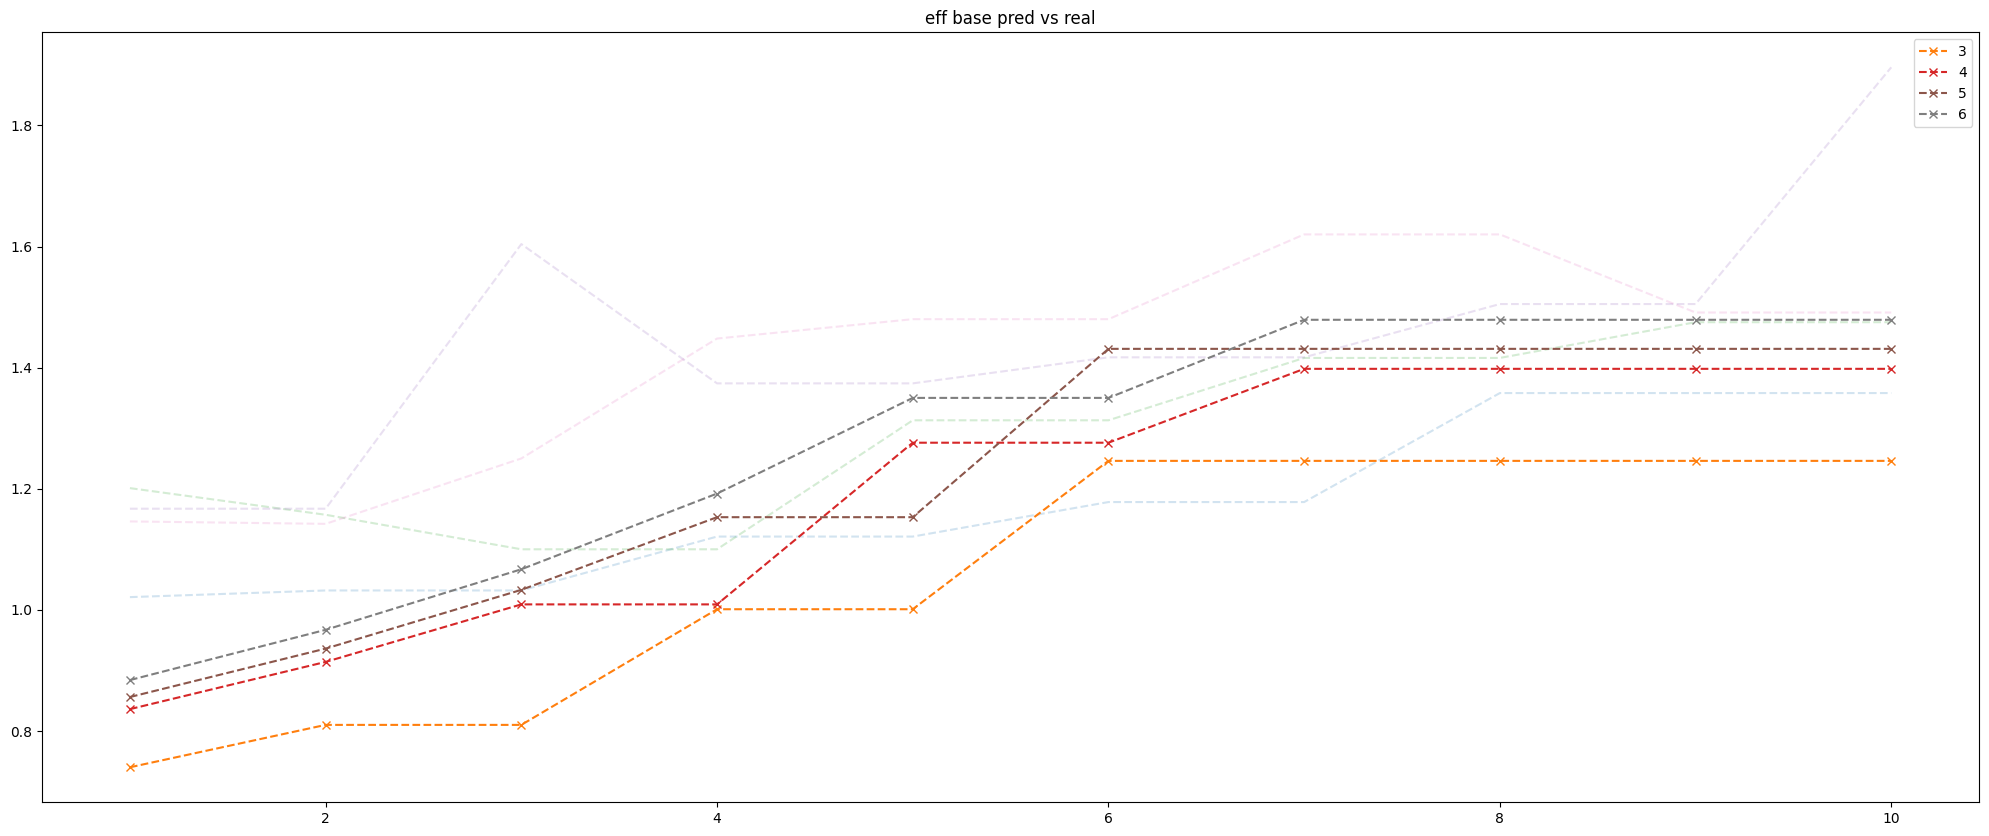

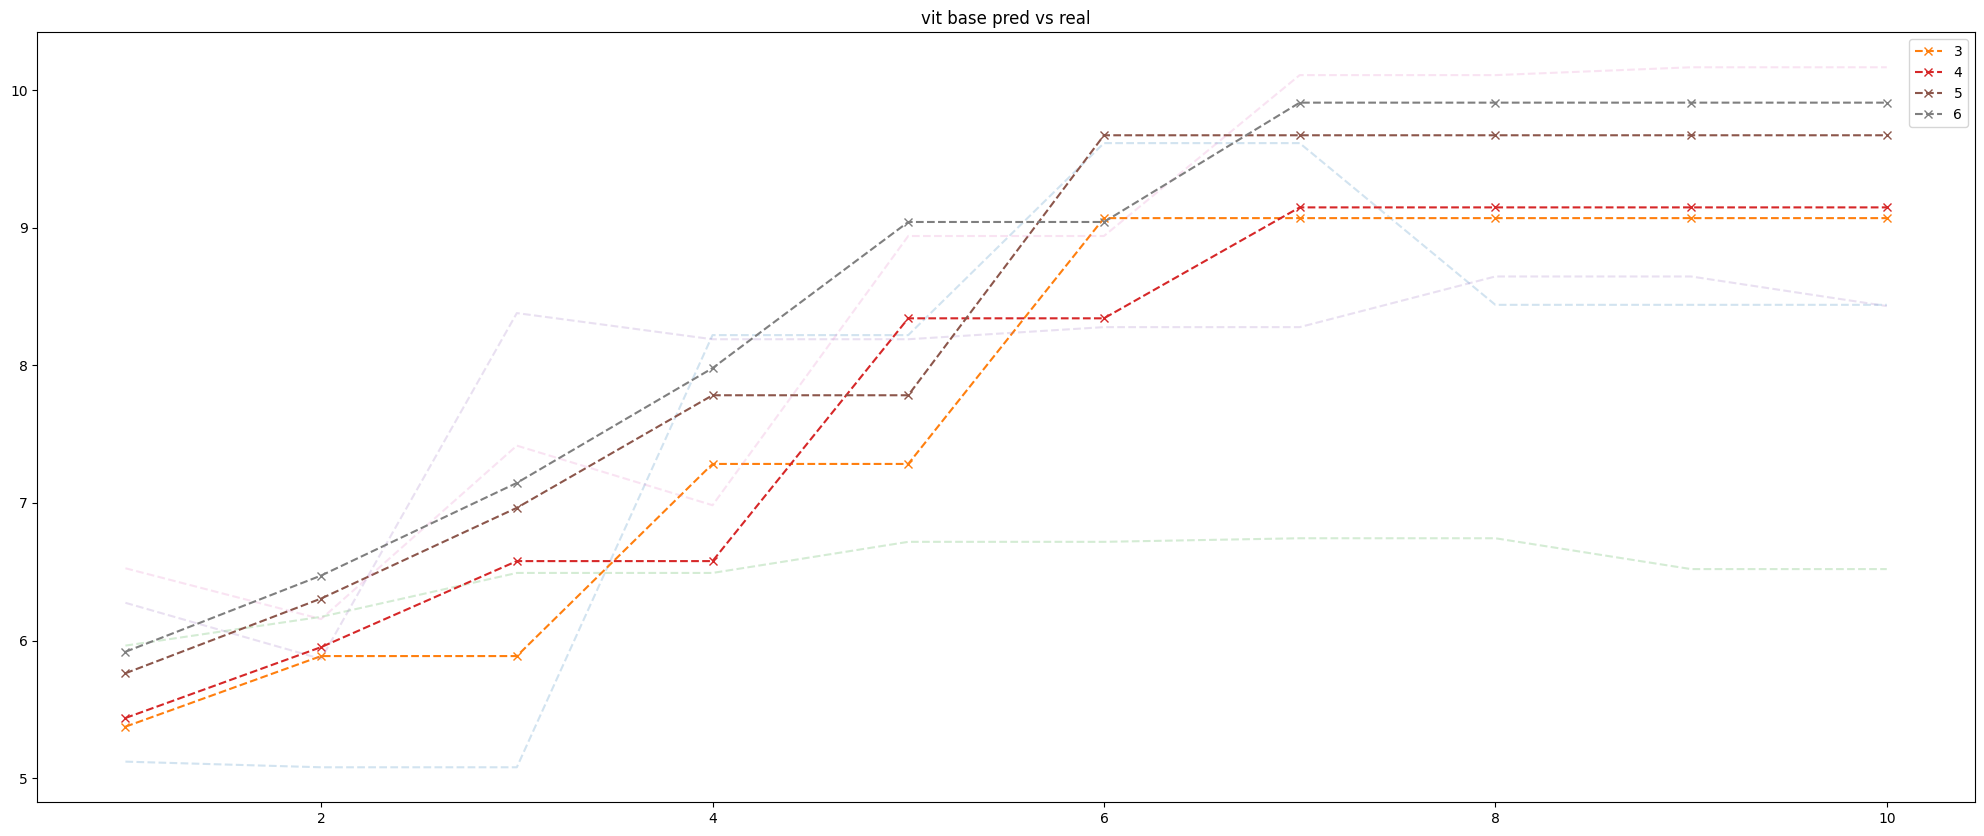

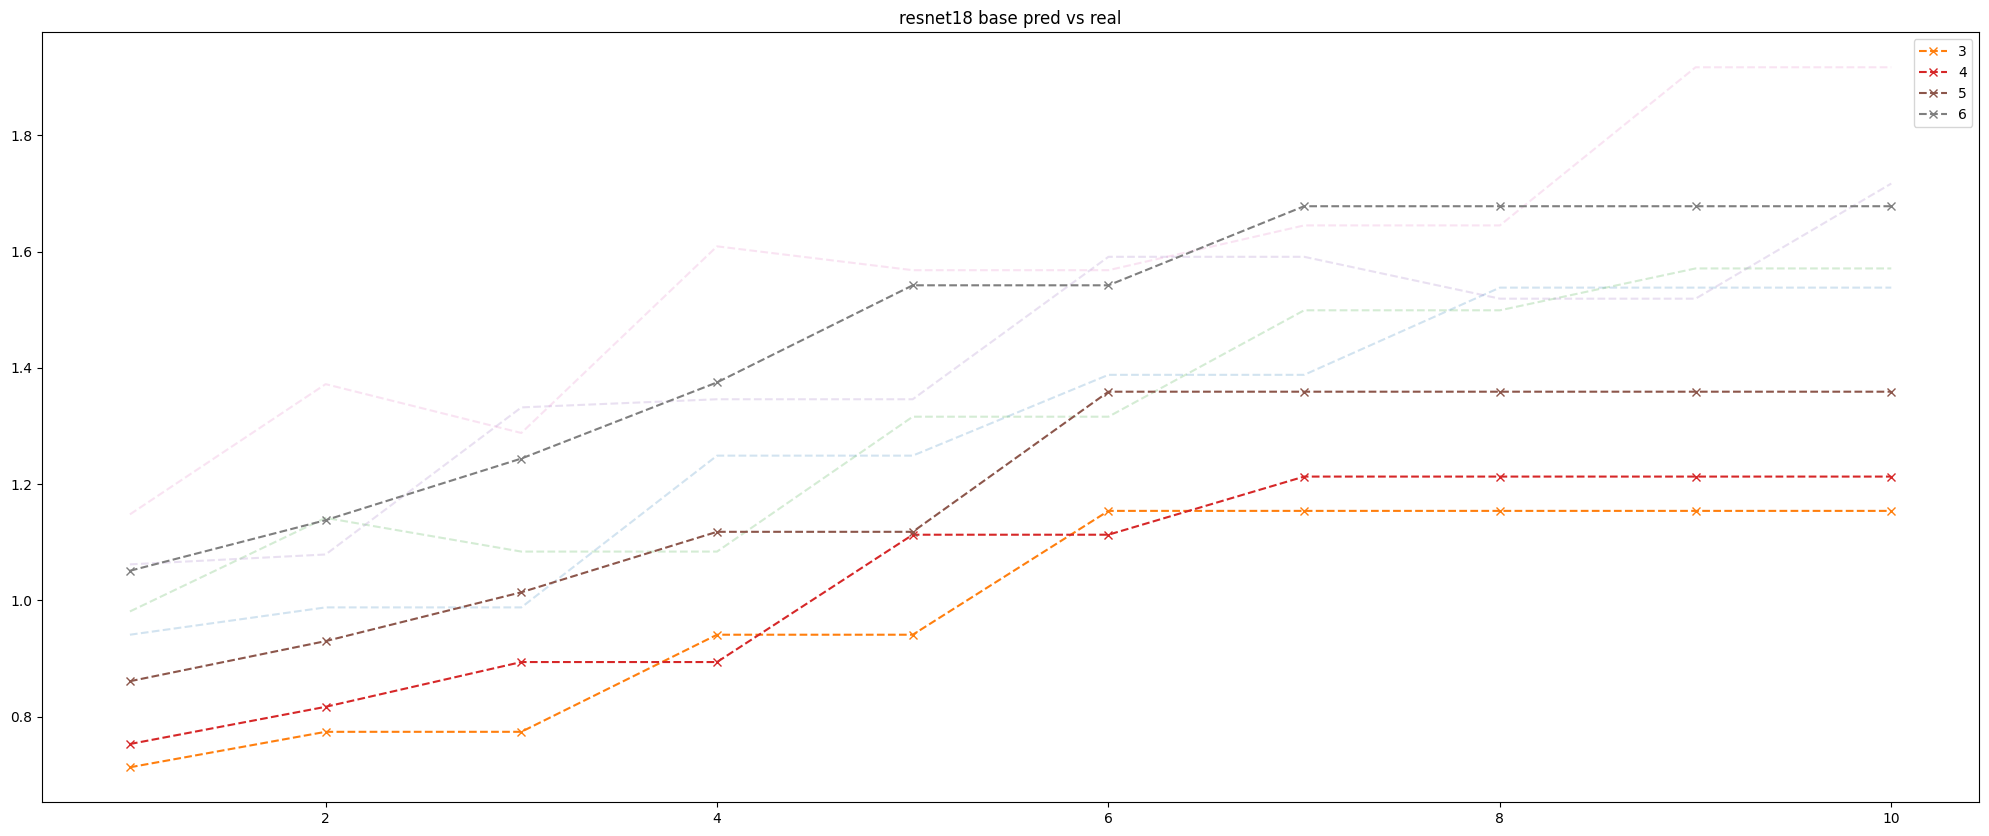

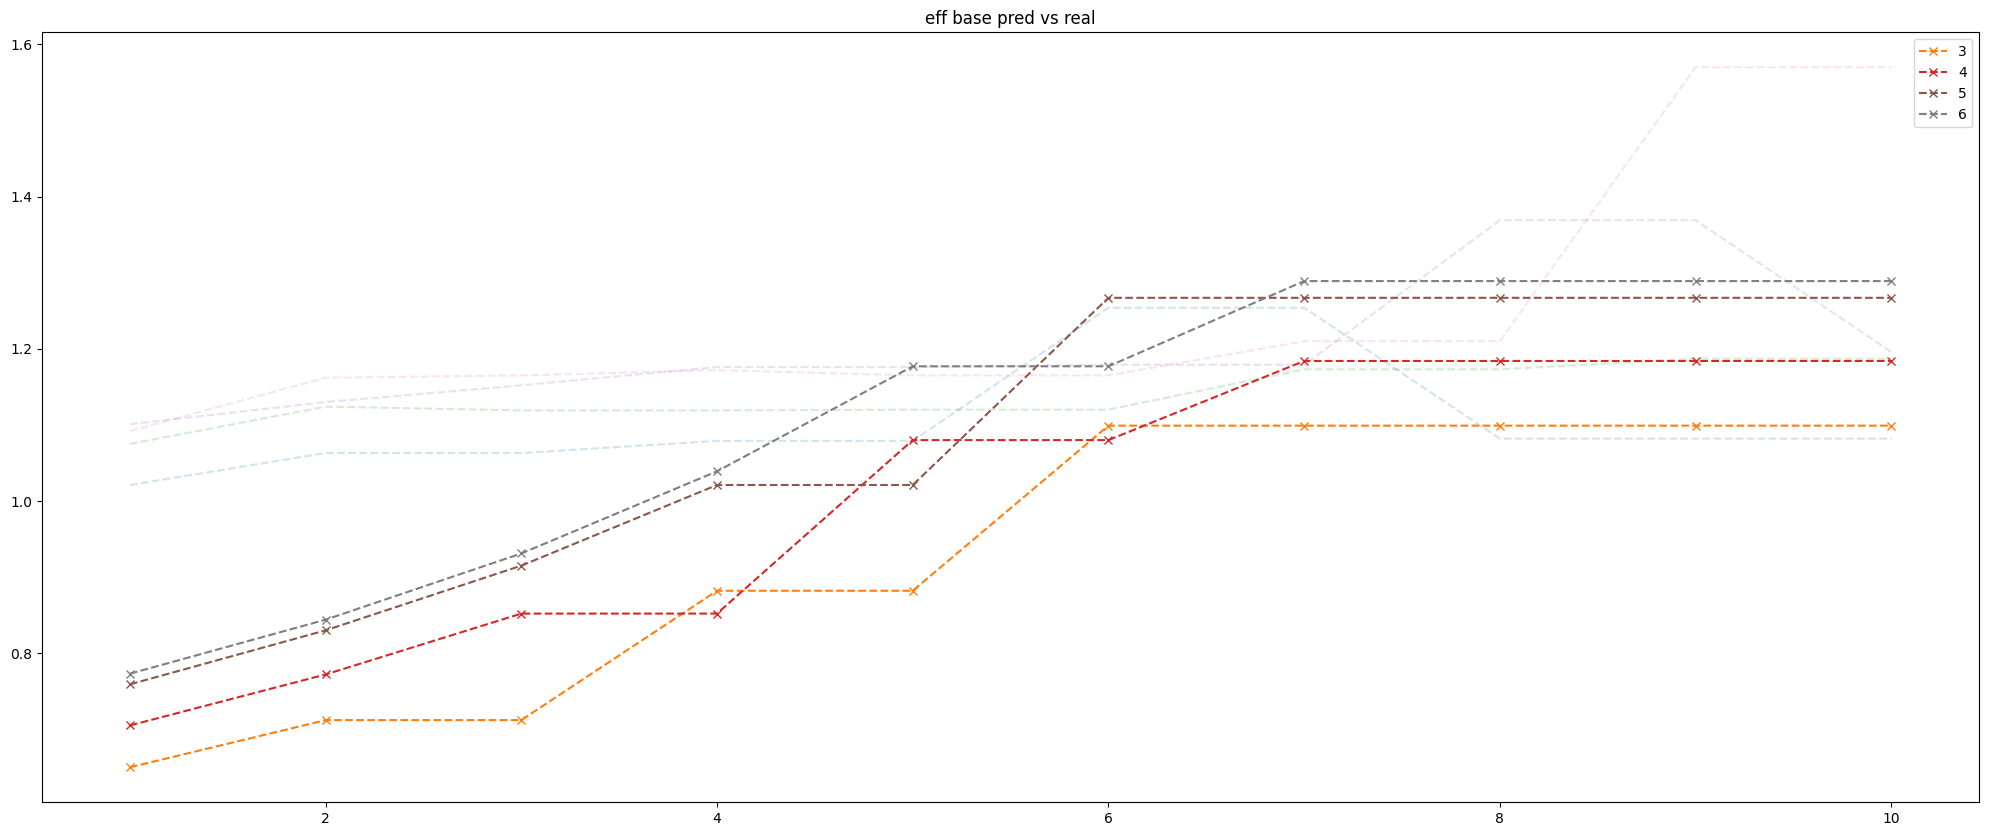

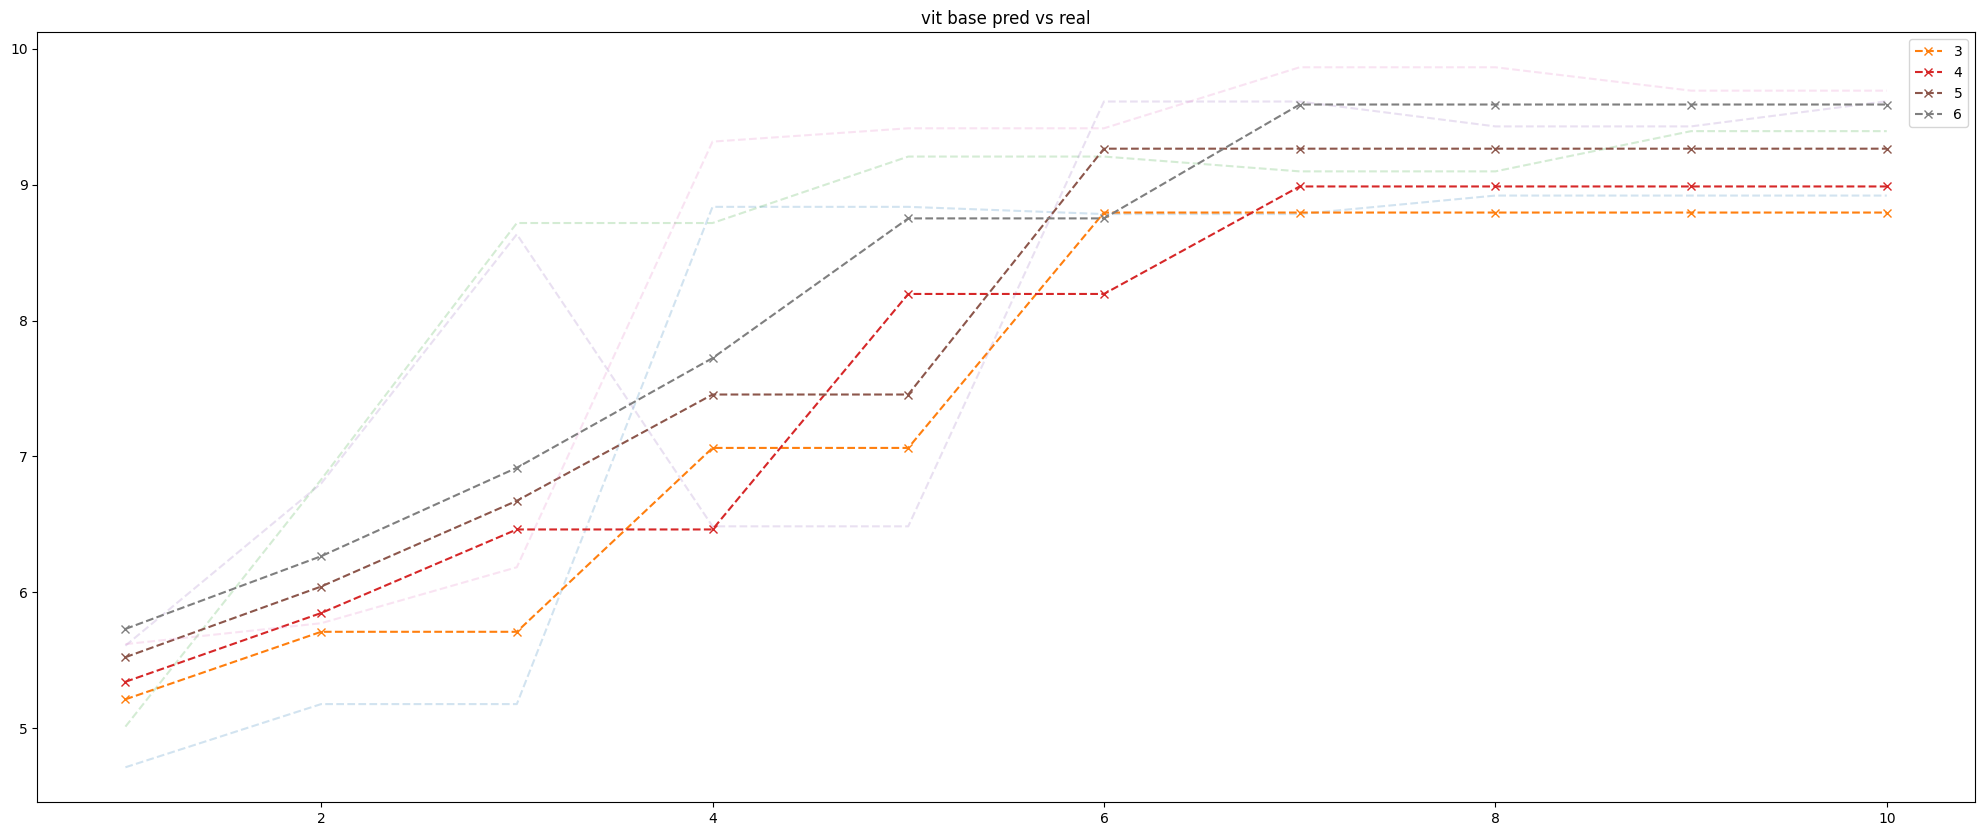

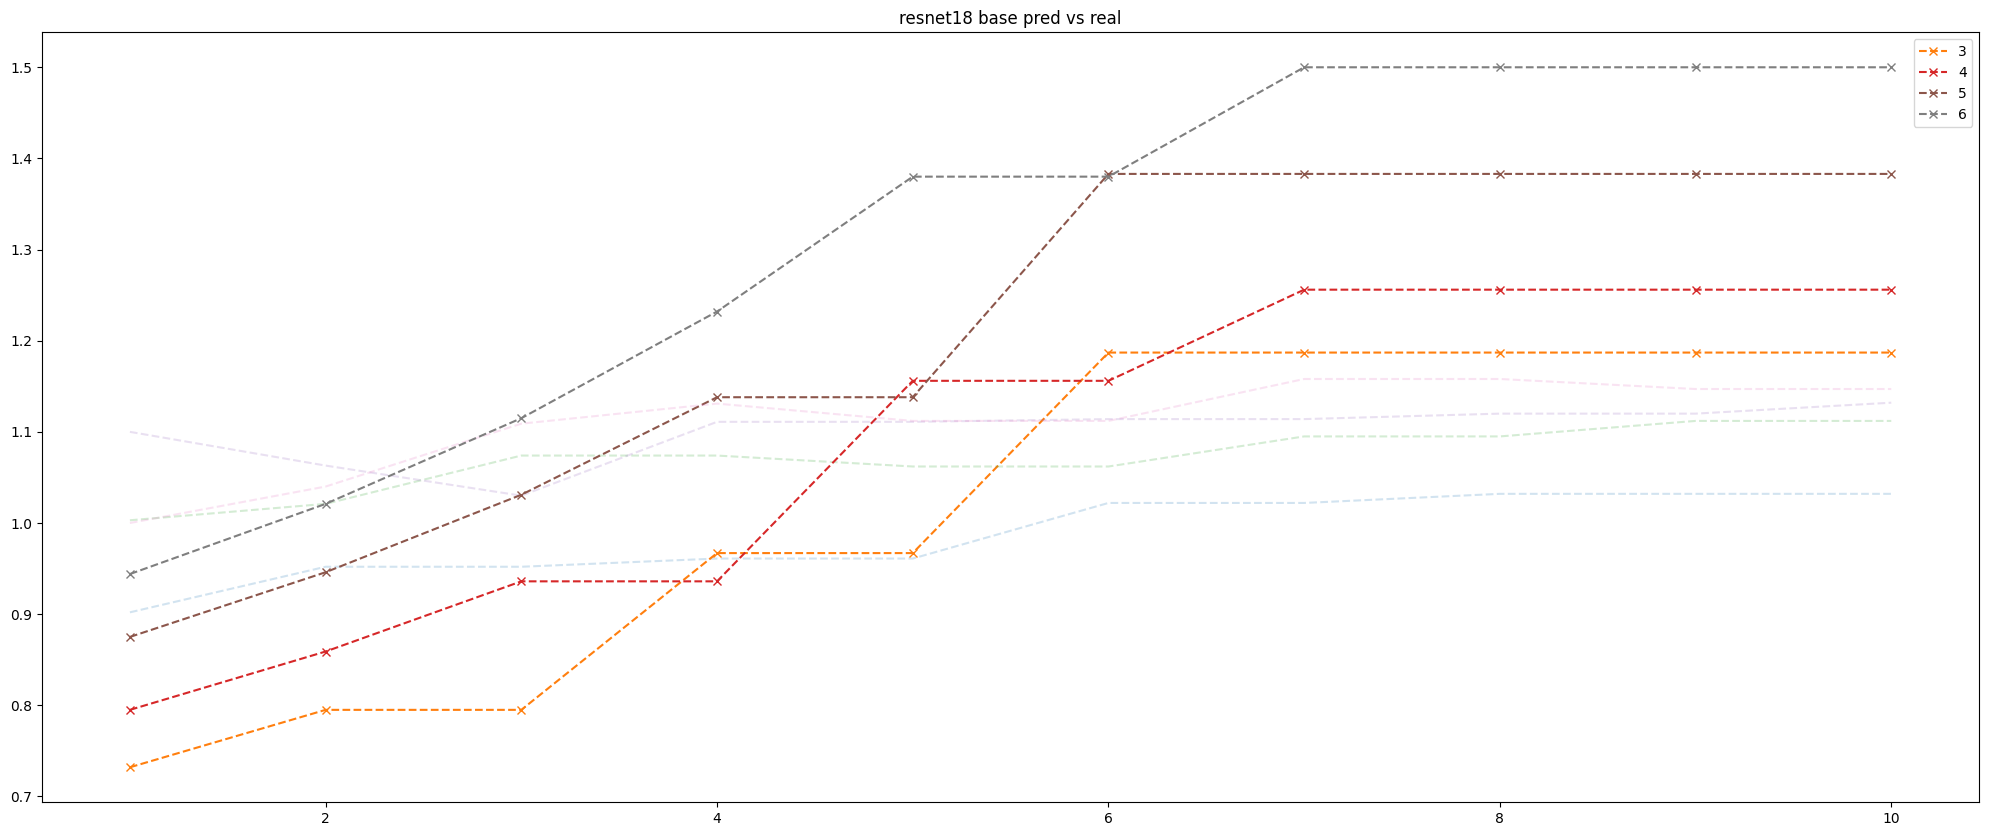

In [509]:
#first result -> rmse, mae, mape low when using the curve 
#x axis is bg_load, y axis is time taken by ml model (batch size=1, batch num=1), each line different splits from 2 to 6

real_maps={}
pred_maps={}
naive_maps={}
for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}
    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", "bramble-2-4", model, world, bg, 1, 1, 240, 'c', col_flag="max")
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred


overall_y={model:[] for model in real_maps}
overall_pred_y = {model:[] for model in real_maps}
overall_naive_pred = {model:[] for model in real_maps}
best_y={model:[] for model in real_maps}

for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(pred_y)
        print(f"rmse c {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae c {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape c {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()
            


real_maps={}
pred_maps={}
naive_maps={}


for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}

    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", "bramble-2-4", model, world, bg, 1, 1, 240, 'nw', col_flag="max")
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred



for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        naive_pred = [naive_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(y)
        overall_naive_pred[model].extend(naive_pred)

        print(f"rmse nw {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae nw {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape nw {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()



for model in real_maps:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print()
    pred_y = overall_naive_pred[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")


In [579]:
#second result -> rmse, mae, mape low when using the curve
#x axis is bg_load, y axis is time taken by ml model (varying batch sizes, batch numbers) for particular input and splits based on input
#showcases depending on how loaded a system is, there is a different answer 

subcluster="bramble-2-4"
detailed_map = {}
bws=[240, 30, 20, 15, 10, 2, 1]
# for bw in [240, 100, 50, 10, 5, 2]:
for bw in bws:
    pred_maps = {}
    real_maps = {}
    # for inp in range(10,60, 10):
    # for inp in [10, 20, 30, 50]:
    for inp in [10]:
        if inp not in real_maps:
            real_maps[inp] = {}
            pred_maps[inp] = {}
            detailed_map[inp]={}
        for model in ["eff", "vit", "resnet18"]:
            if model not in real_maps[inp]:
                real_maps[inp][model]={}
                pred_maps[inp][model]={}
                detailed_map[inp][model]={}
            for world in range(3,7):
                if world not in real_maps[inp][model]:
                    real_maps[inp][model][world]={}
                    pred_maps[inp][model][world]={}
                    detailed_map[inp][model][world]={}

                # for bg in range(1,map_sub[subcluster]-world+1):
                # for bg in range(1,12):
                for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.1, map_sub[subcluster]*0.5, map_sub[subcluster]*0.9]:
                # for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.9]:
                    # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
                    #pick best batch size and batch num per bg load
                    best_real_th = 0
                    best_pred_th = 0
                    saved_real_bs, saved_real_bn = 0, 0
                    saved_pred_bs, saved_pred_bn = 0, 0
                    saved_real_rt, saved_pred_rt = 0, 0

                    # for bs in range(1,inp):
                    for bs in [1, 2, 5, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'c', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", subcluster, model, world, bg, bs, bn, bw, 'c', col_flag="max")
                            # print(bw, model, world, 100*( (bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "c"])
                            
                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "c", float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"])
                    continue
                    best_real_th, best_pred_th = 0,0
                    # for bs in range(1,inp):
                    for bs in [1, 2, 5, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'nw', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", subcluster, model, world, bg, bs, bn, bw, 'nw', col_flag="max")
                            # print(bw, model, world, 100*((bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "nw"])

                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "nw", float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"])

    # f=open(f"exploration.detailed.{bw}.nw", "w")
    f=open(f"exploration.detailed.{bw}", "w")
    f.writelines([f"{detailed_map}\n"])
    f.close()
    # f=open(f"exploration.dict.{bw}.mean.lim", "w")
    # f.writelines([f"{real_maps}\n", f"{pred_maps}\n"])

    # print(real_maps.keys())
    # # for inp in real_maps:
    # #     print(inp)
    # f.close()



fmt is bn_bs
overall rmse eff: 1.604573845432621
overall mae eff:  1.087560267857143
overall mape eff: 9.171092437470966%

naive overall rmse eff: 4.8286271775363705
naive overall mae eff:  4.024696428571429
naive overall mape eff: 42.035873384289914%

overall rmse resnet18: 1.3394381909631792
overall mae resnet18:  1.1053995535714285
overall mape resnet18: 6.091806617787726%

naive overall rmse resnet18: 2.984031014955154
naive overall mae resnet18:  2.5215625000000004
naive overall mape resnet18: 17.457572616040668%

overall rmse vit: 6.980317931928572
overall mae vit:  4.836716517857142
overall mape vit: 5.086937383165765%

naive overall rmse vit: 21.523577051906937
naive overall mae vit:  17.691453125
naive overall mape vit: 21.503895725091887%



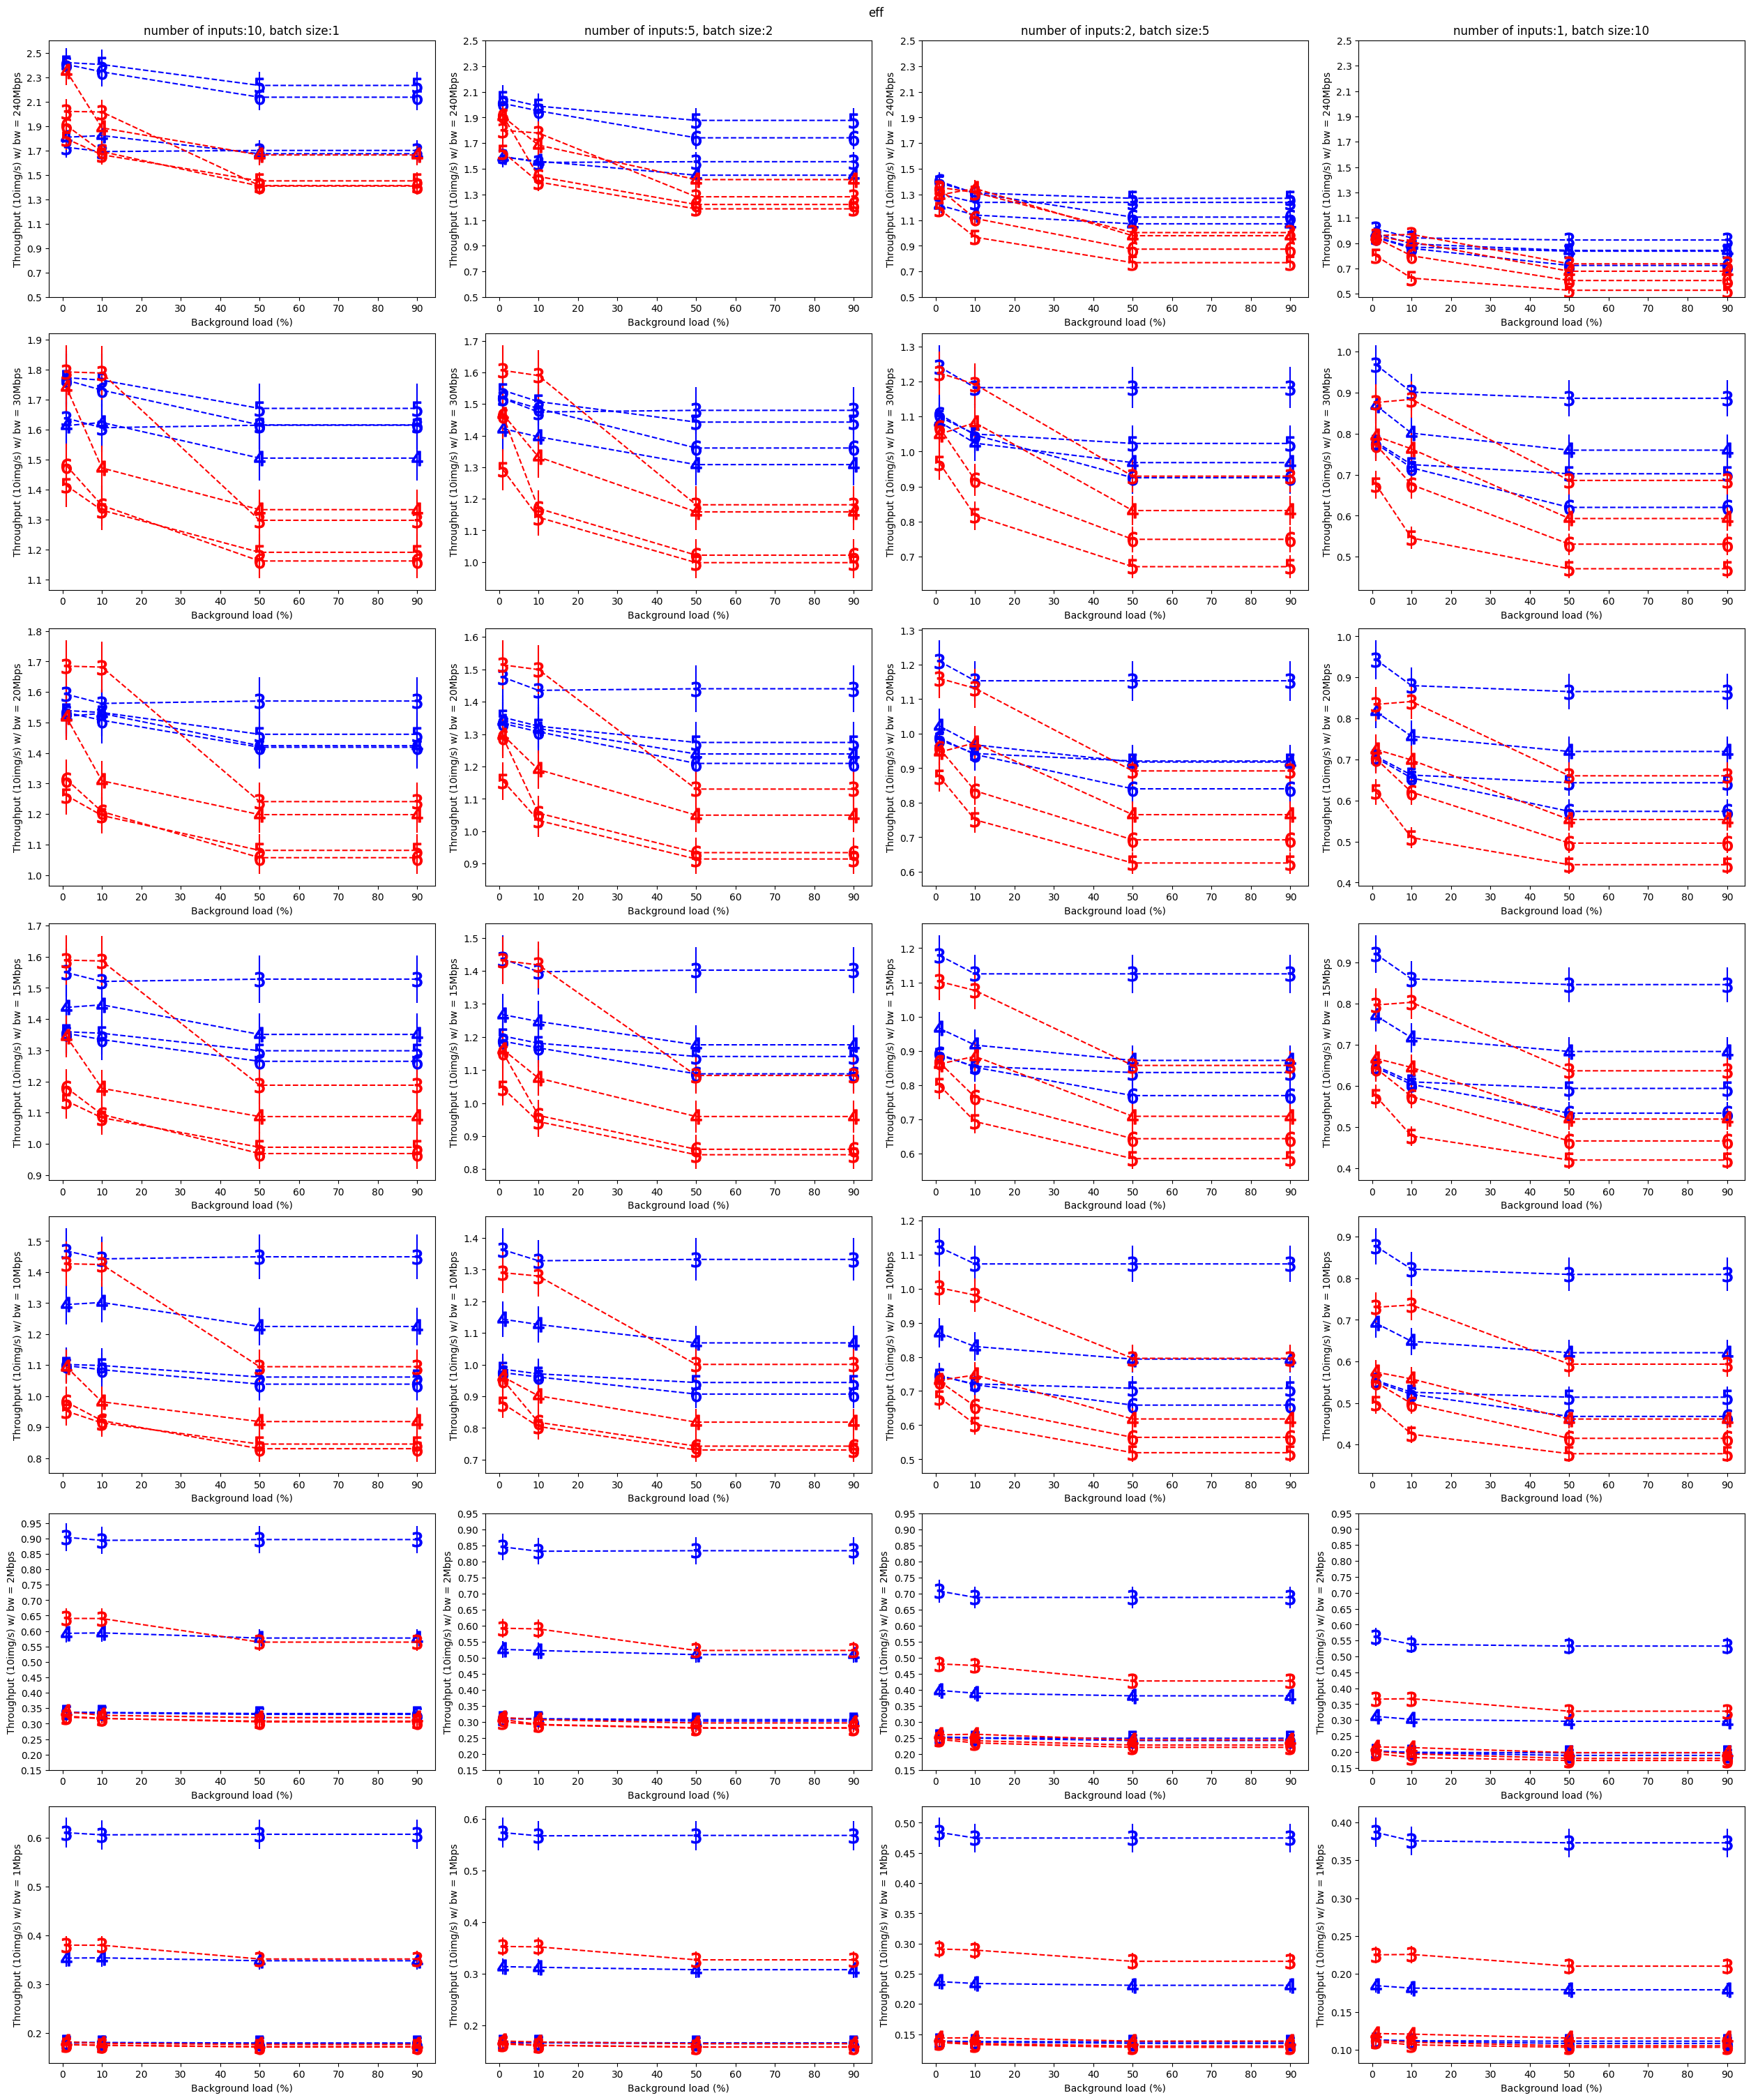

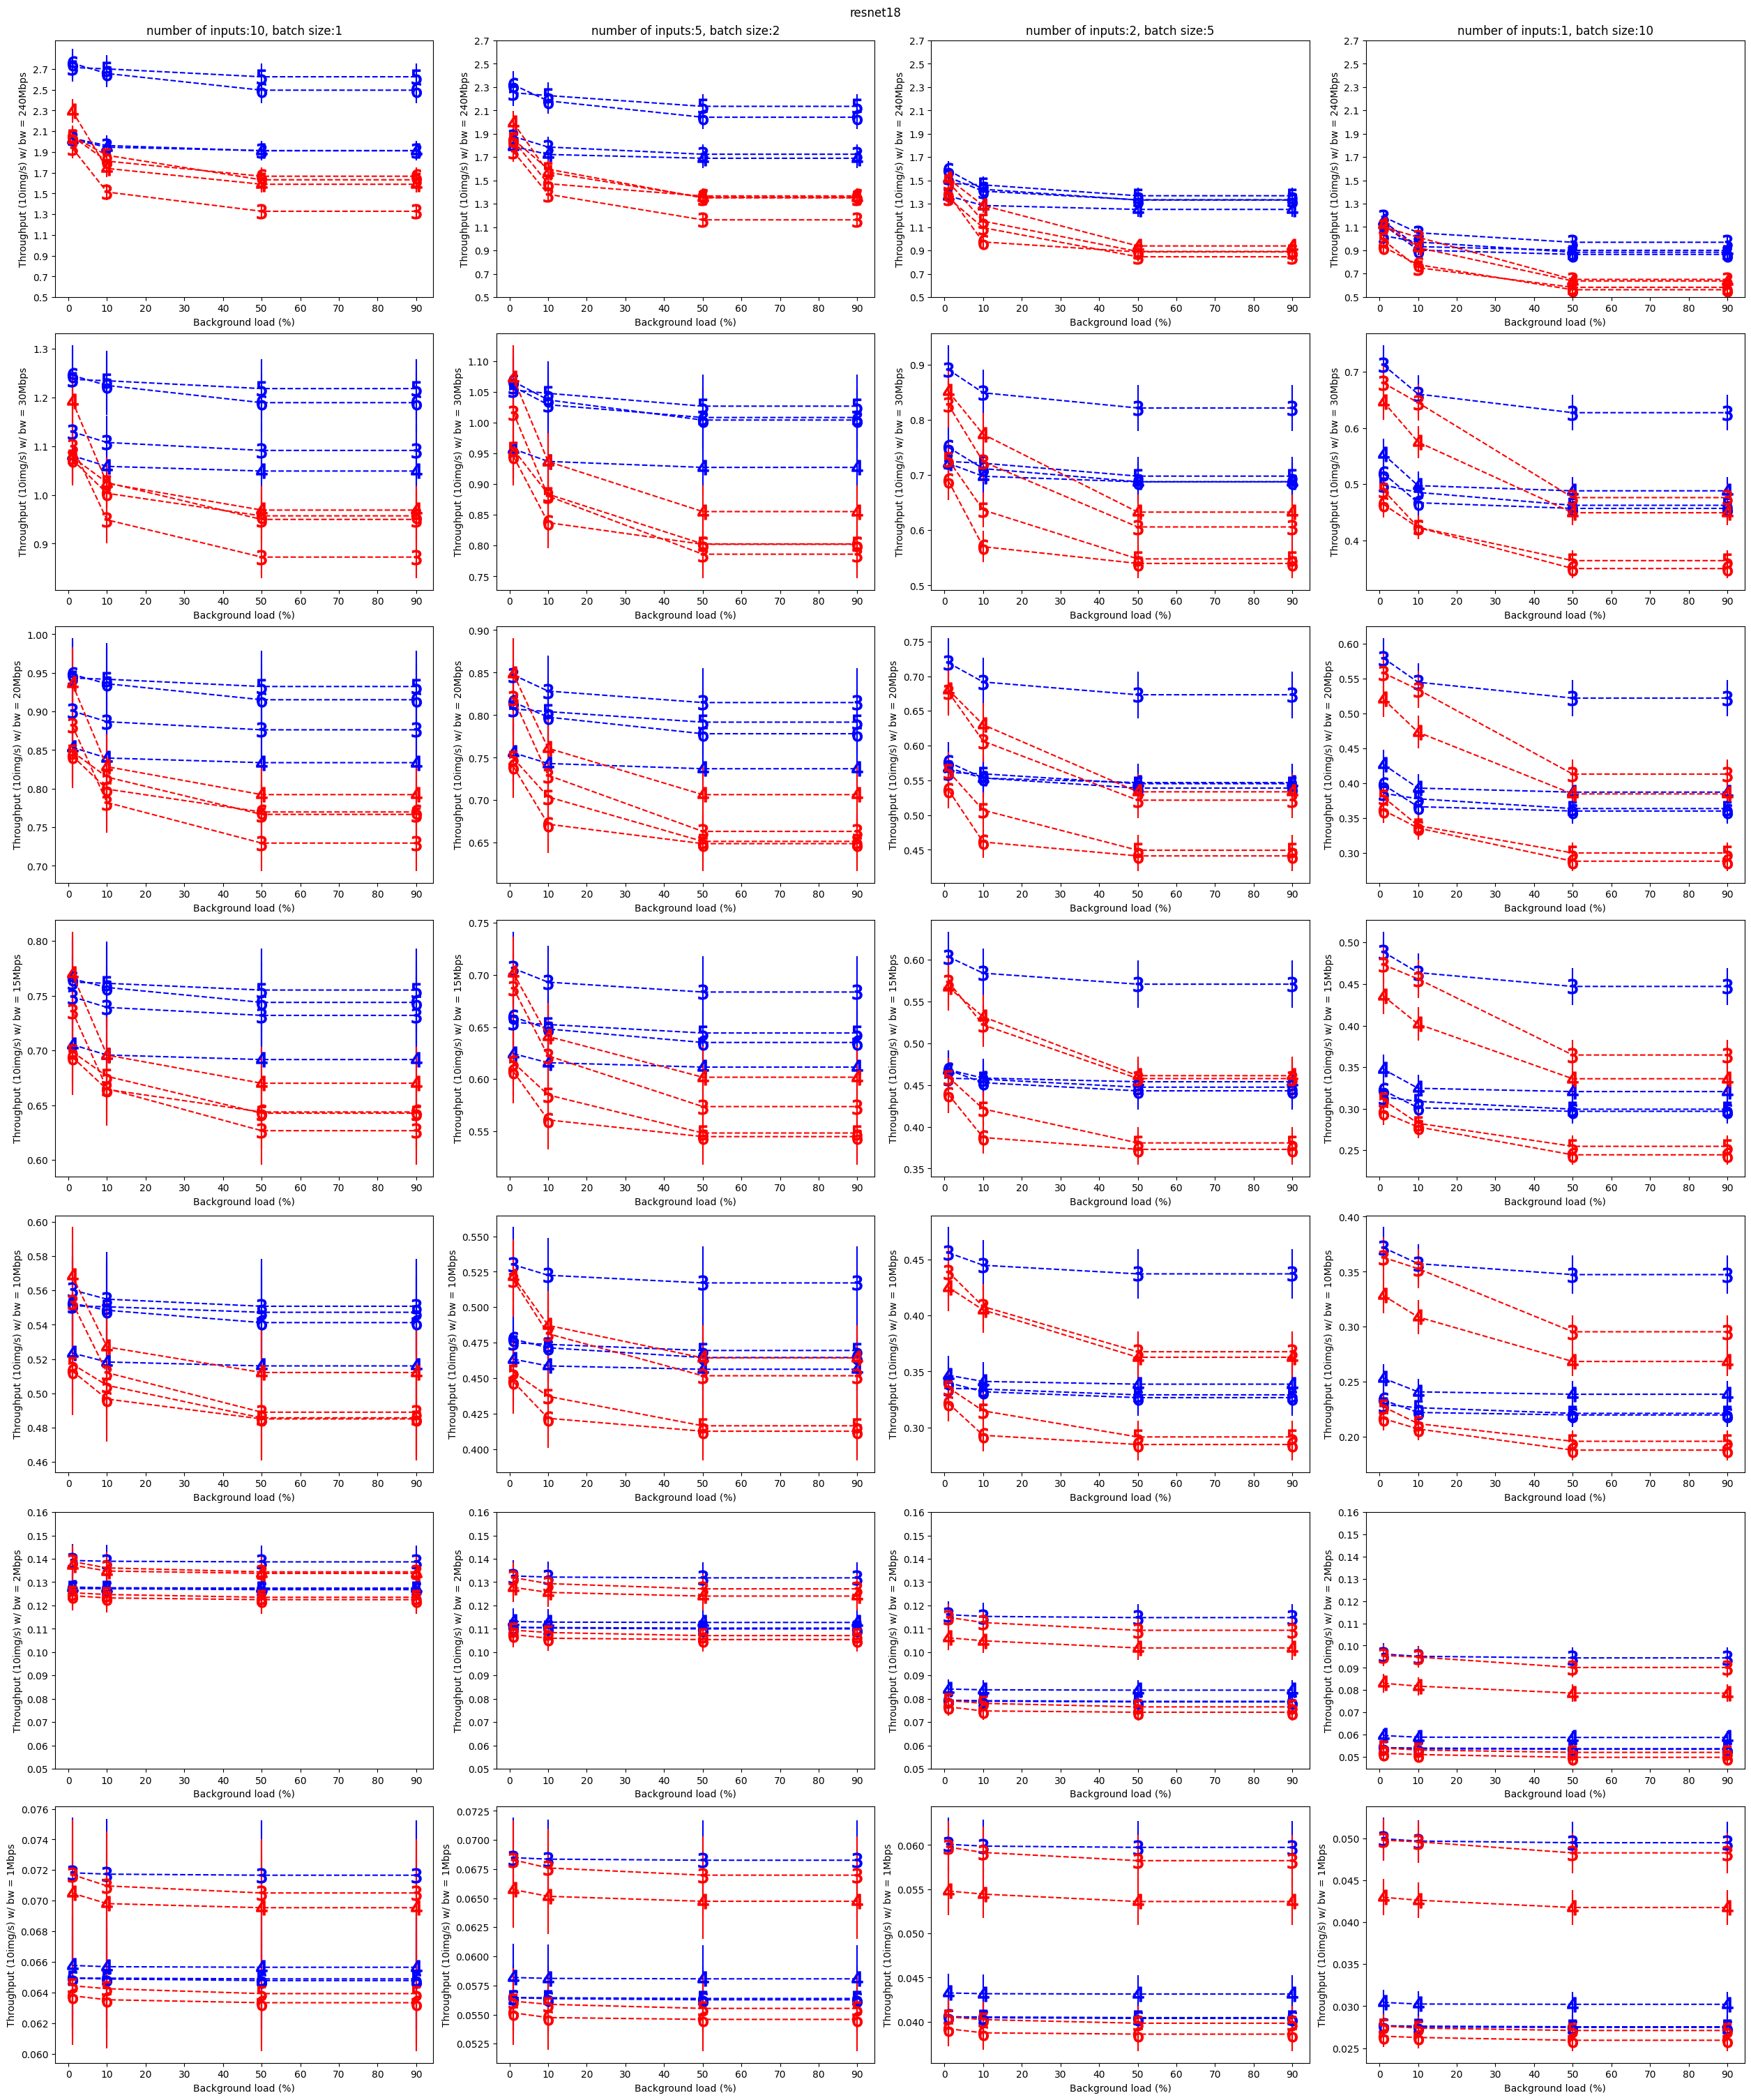

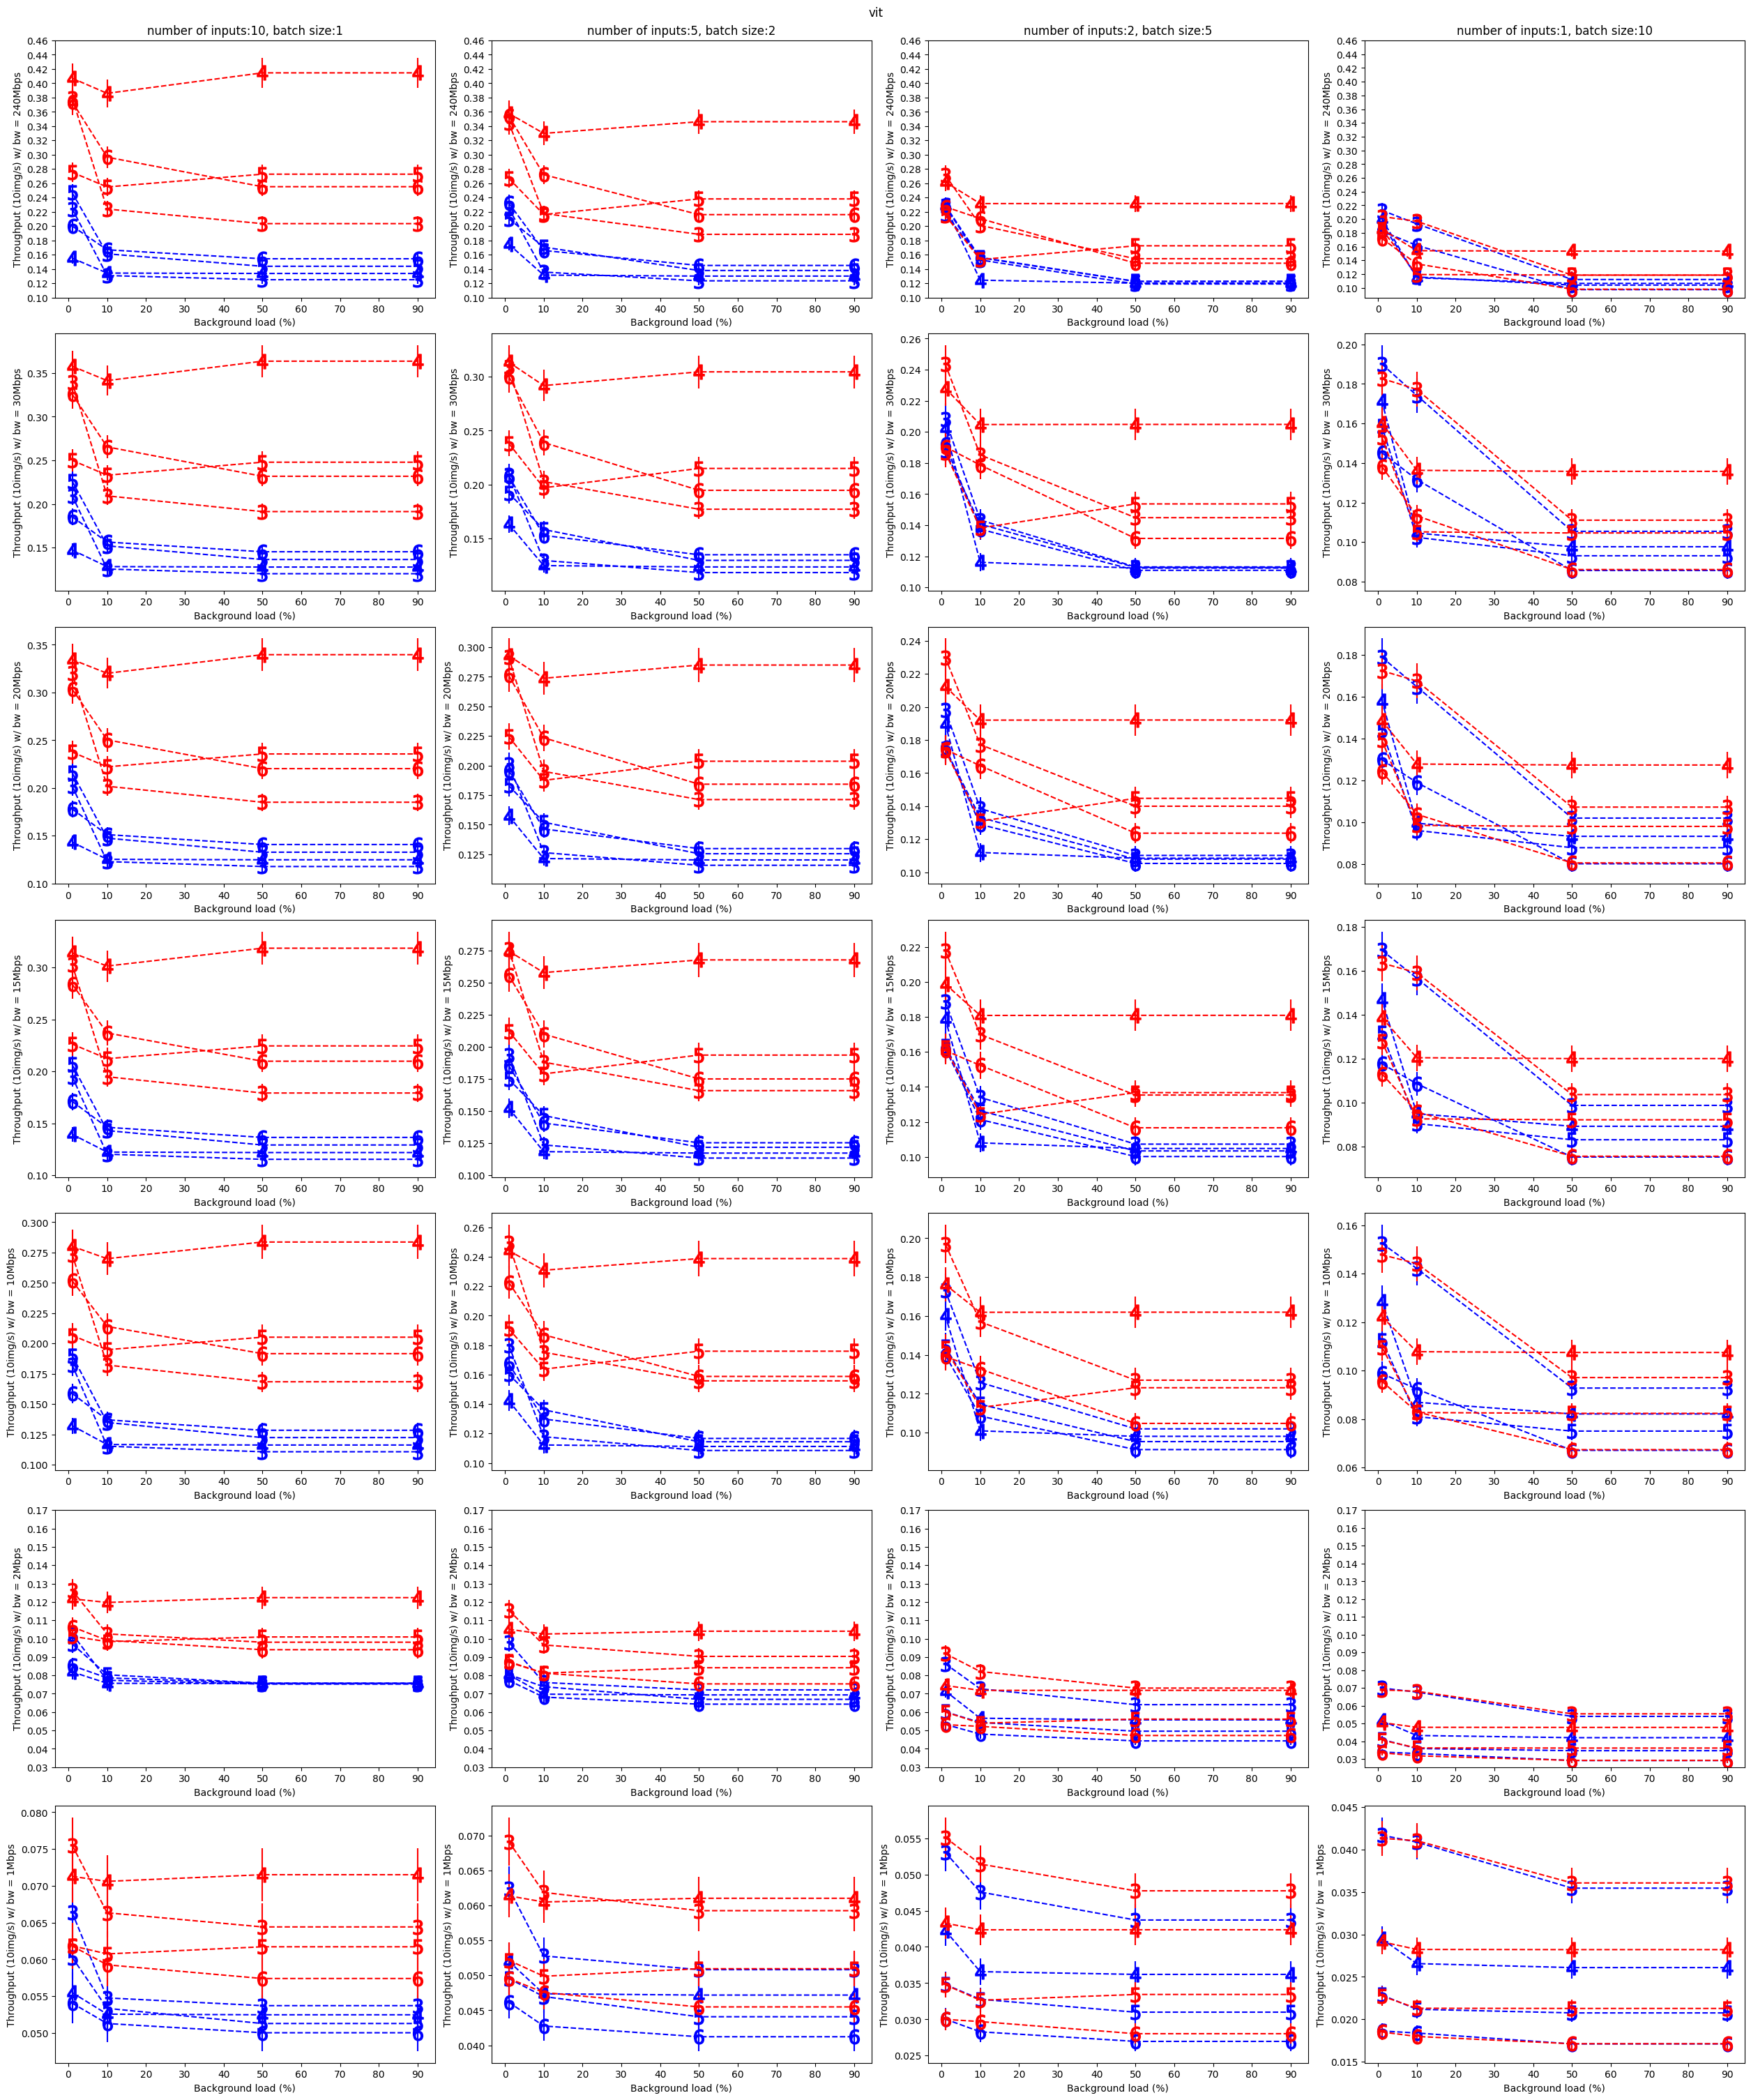

In [582]:
# bws=[240, 2]
bws=[240, 30, 20, 15, 10, 2, 1]

combos = [[1,10], [2,5], [5,2], [10,1]]
# eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
m=["eff", "resnet18","vit"]
overall_y = {model:[] for model in m }
overall_pred_y={model:[] for model in m}
overall_naive_y={model:[] for model in m}
for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    f=open(f"exploration.detailed.{bw}.nw", "r")
    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            if model=="eff":
                eff_fig.suptitle(model)
            elif model=="resnet18":
                res_fig.suptitle(model)
            elif model=="vit":
                vit_fig.suptitle(model)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                # detailed_map[inp][model][world][x[0]]=[]
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    if model=="eff":
                        axs = eff_axs[bw_ind][ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][ind]
                    overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                    overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                    overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])

                    y=[ 10/detailed_map[inp][model][world][i][ind][0] for i in x]
                    pred_y = [10/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"

                    y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar
                    axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="blue")
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"number of inputs:{num_inp}, batch size:{bs}")
                    axs.set_xticks(np.arange(0,100,10))
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,2.6, 0.2))
                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==2:
                            axs.set_yticks(np.arange(0.15, 1, 0.05))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 2.8, 0.2))
                        if bw==2:
                            axs.set_yticks(np.arange(0.05, 0.17, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.48, 0.02))
                        if bw==2:
                            axs.set_yticks(np.arange(0.03, 0.18, 0.01))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
                
                    # str_label = [f"{detailed_map[inp][model][world][i][1]}_{detailed_map[inp][model][world][i][2]}" for i in x]
print(f"fmt is bn_bs")

for model in m:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    # print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print()
    pred_y = overall_naive_y[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")
    print()


for bw_ind, bw in enumerate(bws):
    f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            if model=="eff":
                eff_fig.suptitle(model)
            elif model=="resnet18":
                res_fig.suptitle(model)
            elif model=="vit":
                vit_fig.suptitle(model)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                # detailed_map[inp][model][world][x[0]]=[]
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    if model=="eff":
                        axs = eff_axs[bw_ind][ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][ind]
                    overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                    overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                    overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])

                    y=[ 10/detailed_map[inp][model][world][i][ind][0] for i in x]
                    pred_y = [10/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"

                    y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar
                    axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="red")
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"number of inputs:{num_inp}, batch size:{bs}")
                    axs.set_xticks(np.arange(0,100,10))
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,2.6, 0.2))
                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==2:
                            axs.set_yticks(np.arange(0.15, 1, 0.05))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 2.8, 0.2))
                        if bw==2:
                            axs.set_yticks(np.arange(0.05, 0.17, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.48, 0.02))
                        if bw==2:
                            axs.set_yticks(np.arange(0.03, 0.18, 0.01))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
           

rmse c eff_10_3 0.8244457532184881
mae c eff_10_3 0.7932000000000002
mape c eff_10_3 16.940730736105763%

rmse nw eff_10_3 1.9604262291654844
mae nw eff_10_3 1.9002000000000003
mape nw eff_10_3 33.471222152581525%

rmse c eff_10_4 0.31553098104623584
mae c eff_10_4 0.27260000000000006
mape c eff_10_4 6.318223048900795%

rmse nw eff_10_4 1.1950324681781663
mae nw eff_10_4 1.1286
mape nw eff_10_4 21.62532468540568%

rmse c eff_10_5 0.8942781446507567
mae c eff_10_5 0.8858
mape c eff_10_5 20.528543845236406%

rmse nw eff_10_5 0.6773672563683601
mae nw eff_10_5 0.6699999999999998
mape nw eff_10_5 16.39510157313649%

rmse c eff_10_6 0.813021401932323
mae c eff_10_6 0.8065999999999999
mape c eff_10_6 18.607899181198317%

rmse nw eff_10_6 0.801334262340005
mae nw eff_10_6 0.7866
mape nw eff_10_6 18.209571526618454%

rmse c vit_10_3 3.4906258178154825
mae c vit_10_3 3.2338000000000013
mape c vit_10_3 12.250881928576426%

rmse nw vit_10_3 15.075321011507516
mae nw vit_10_3 14.667999999999997
ma

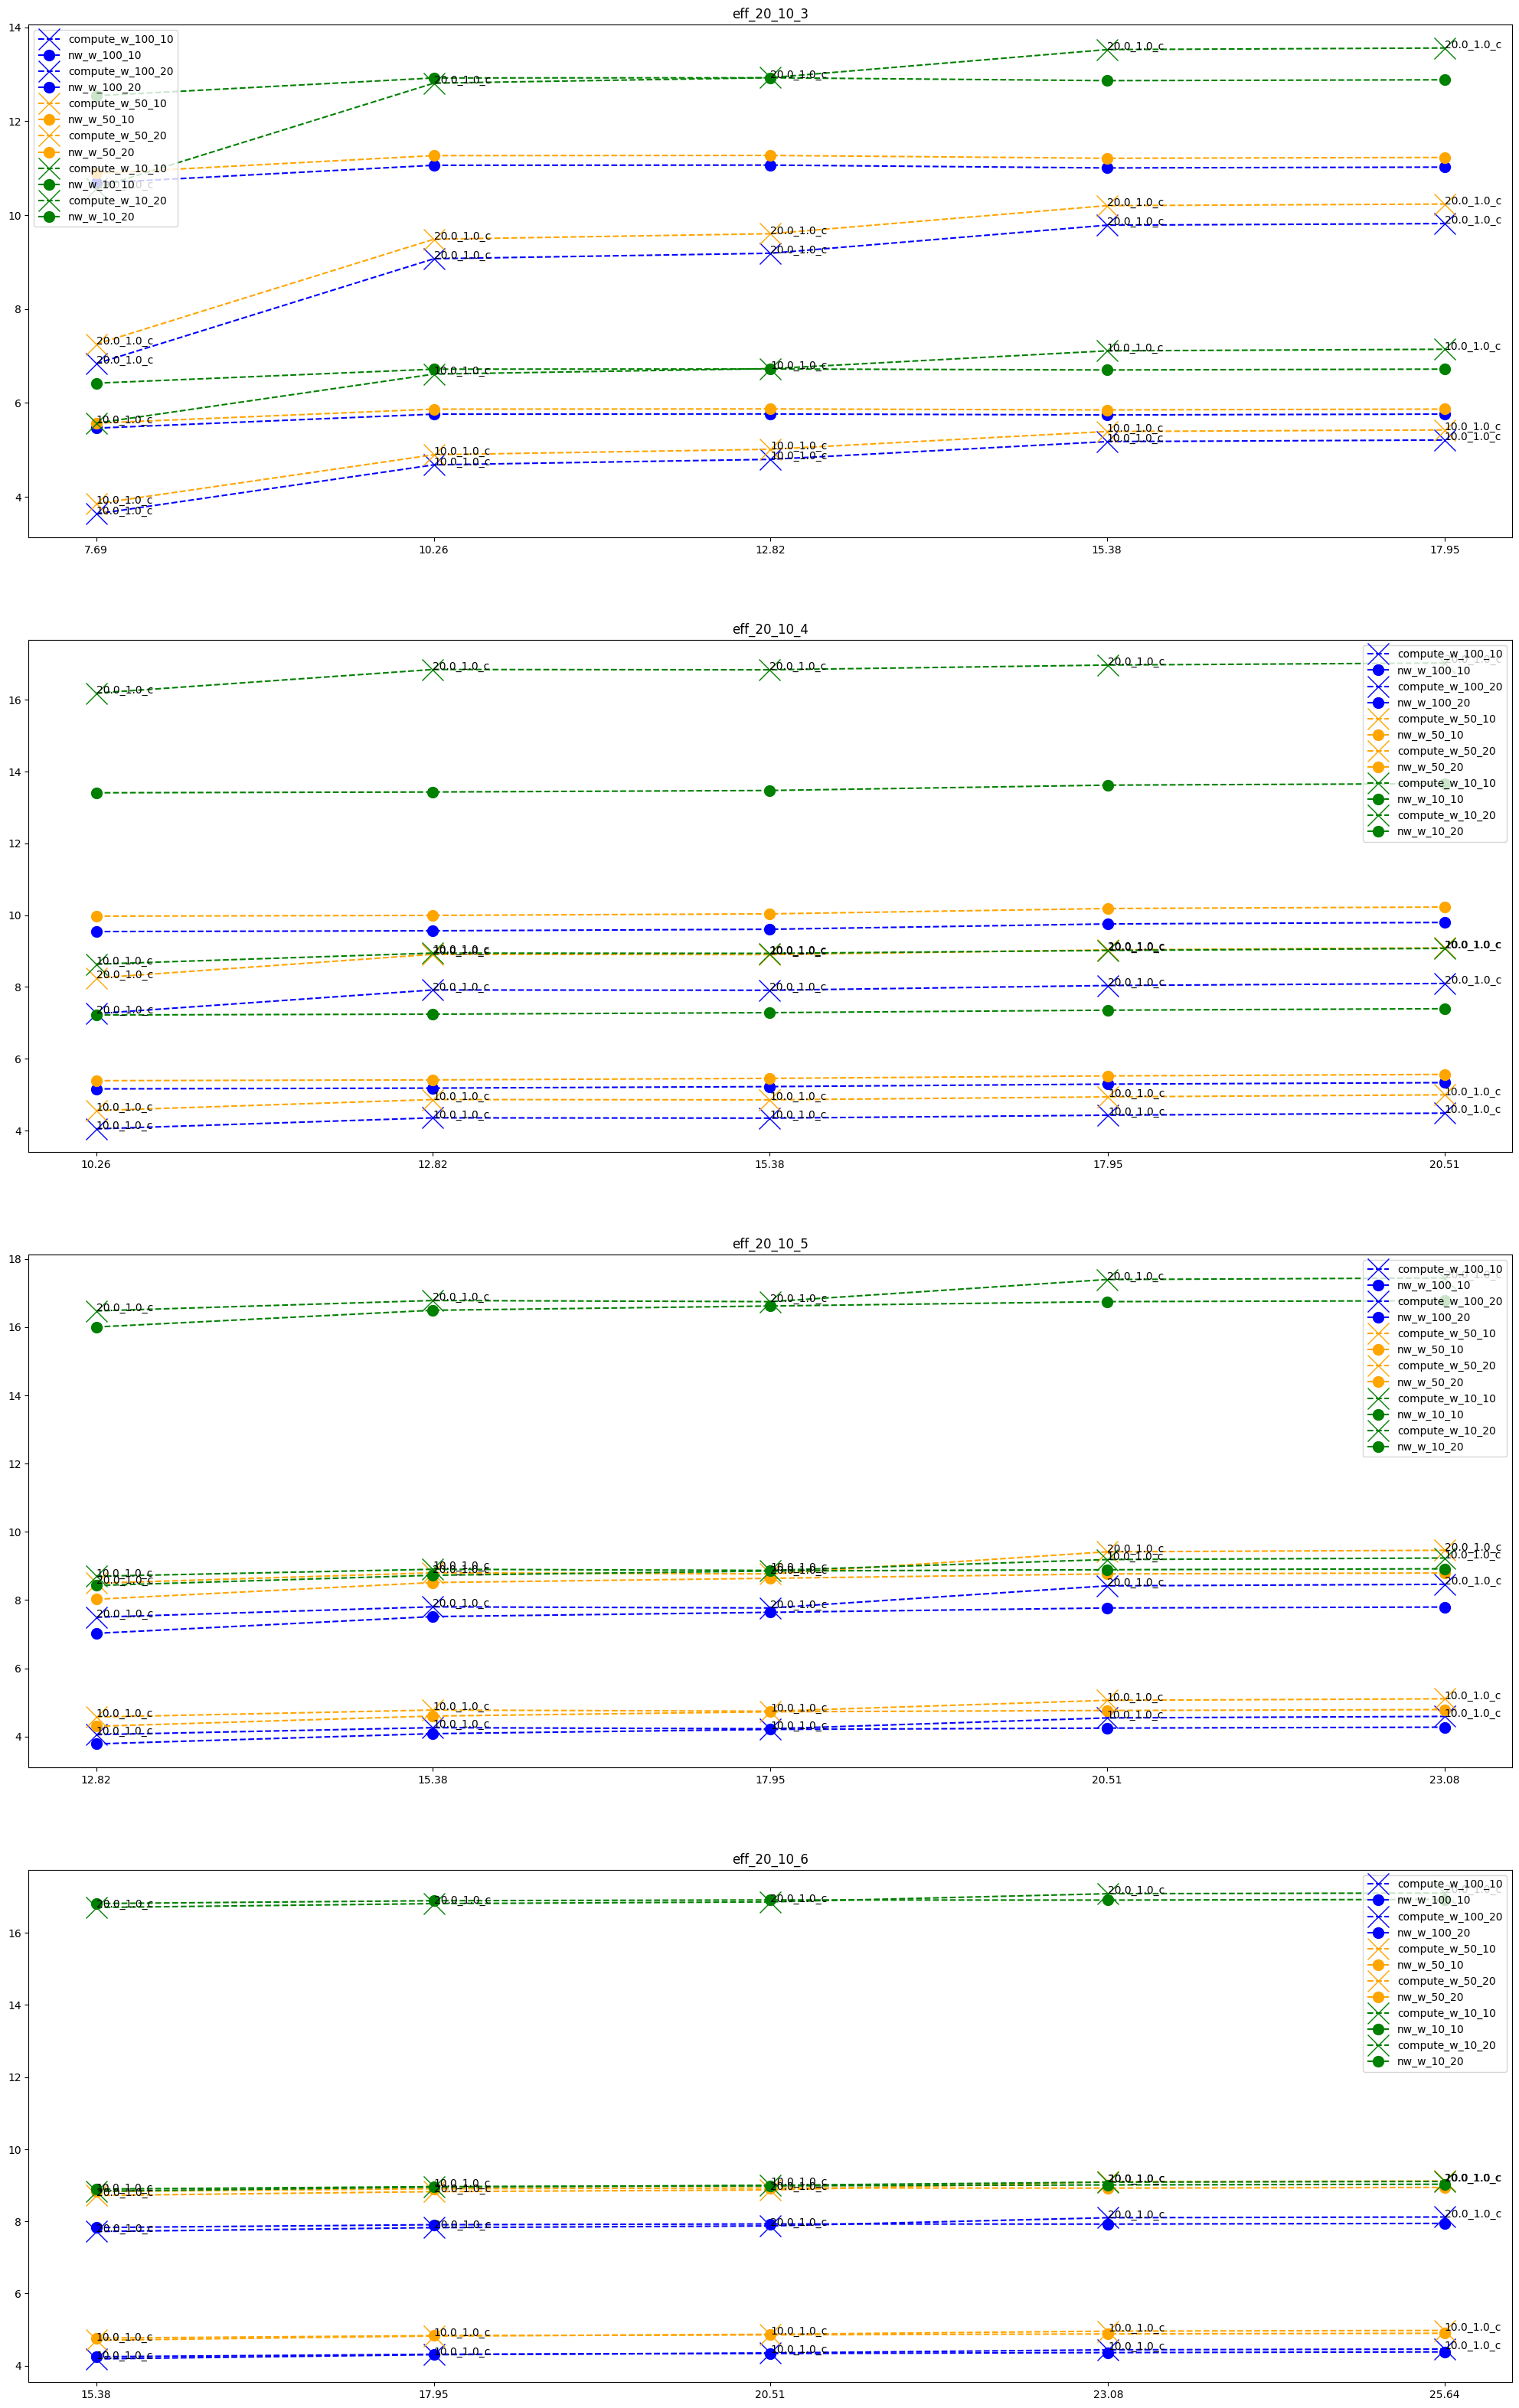

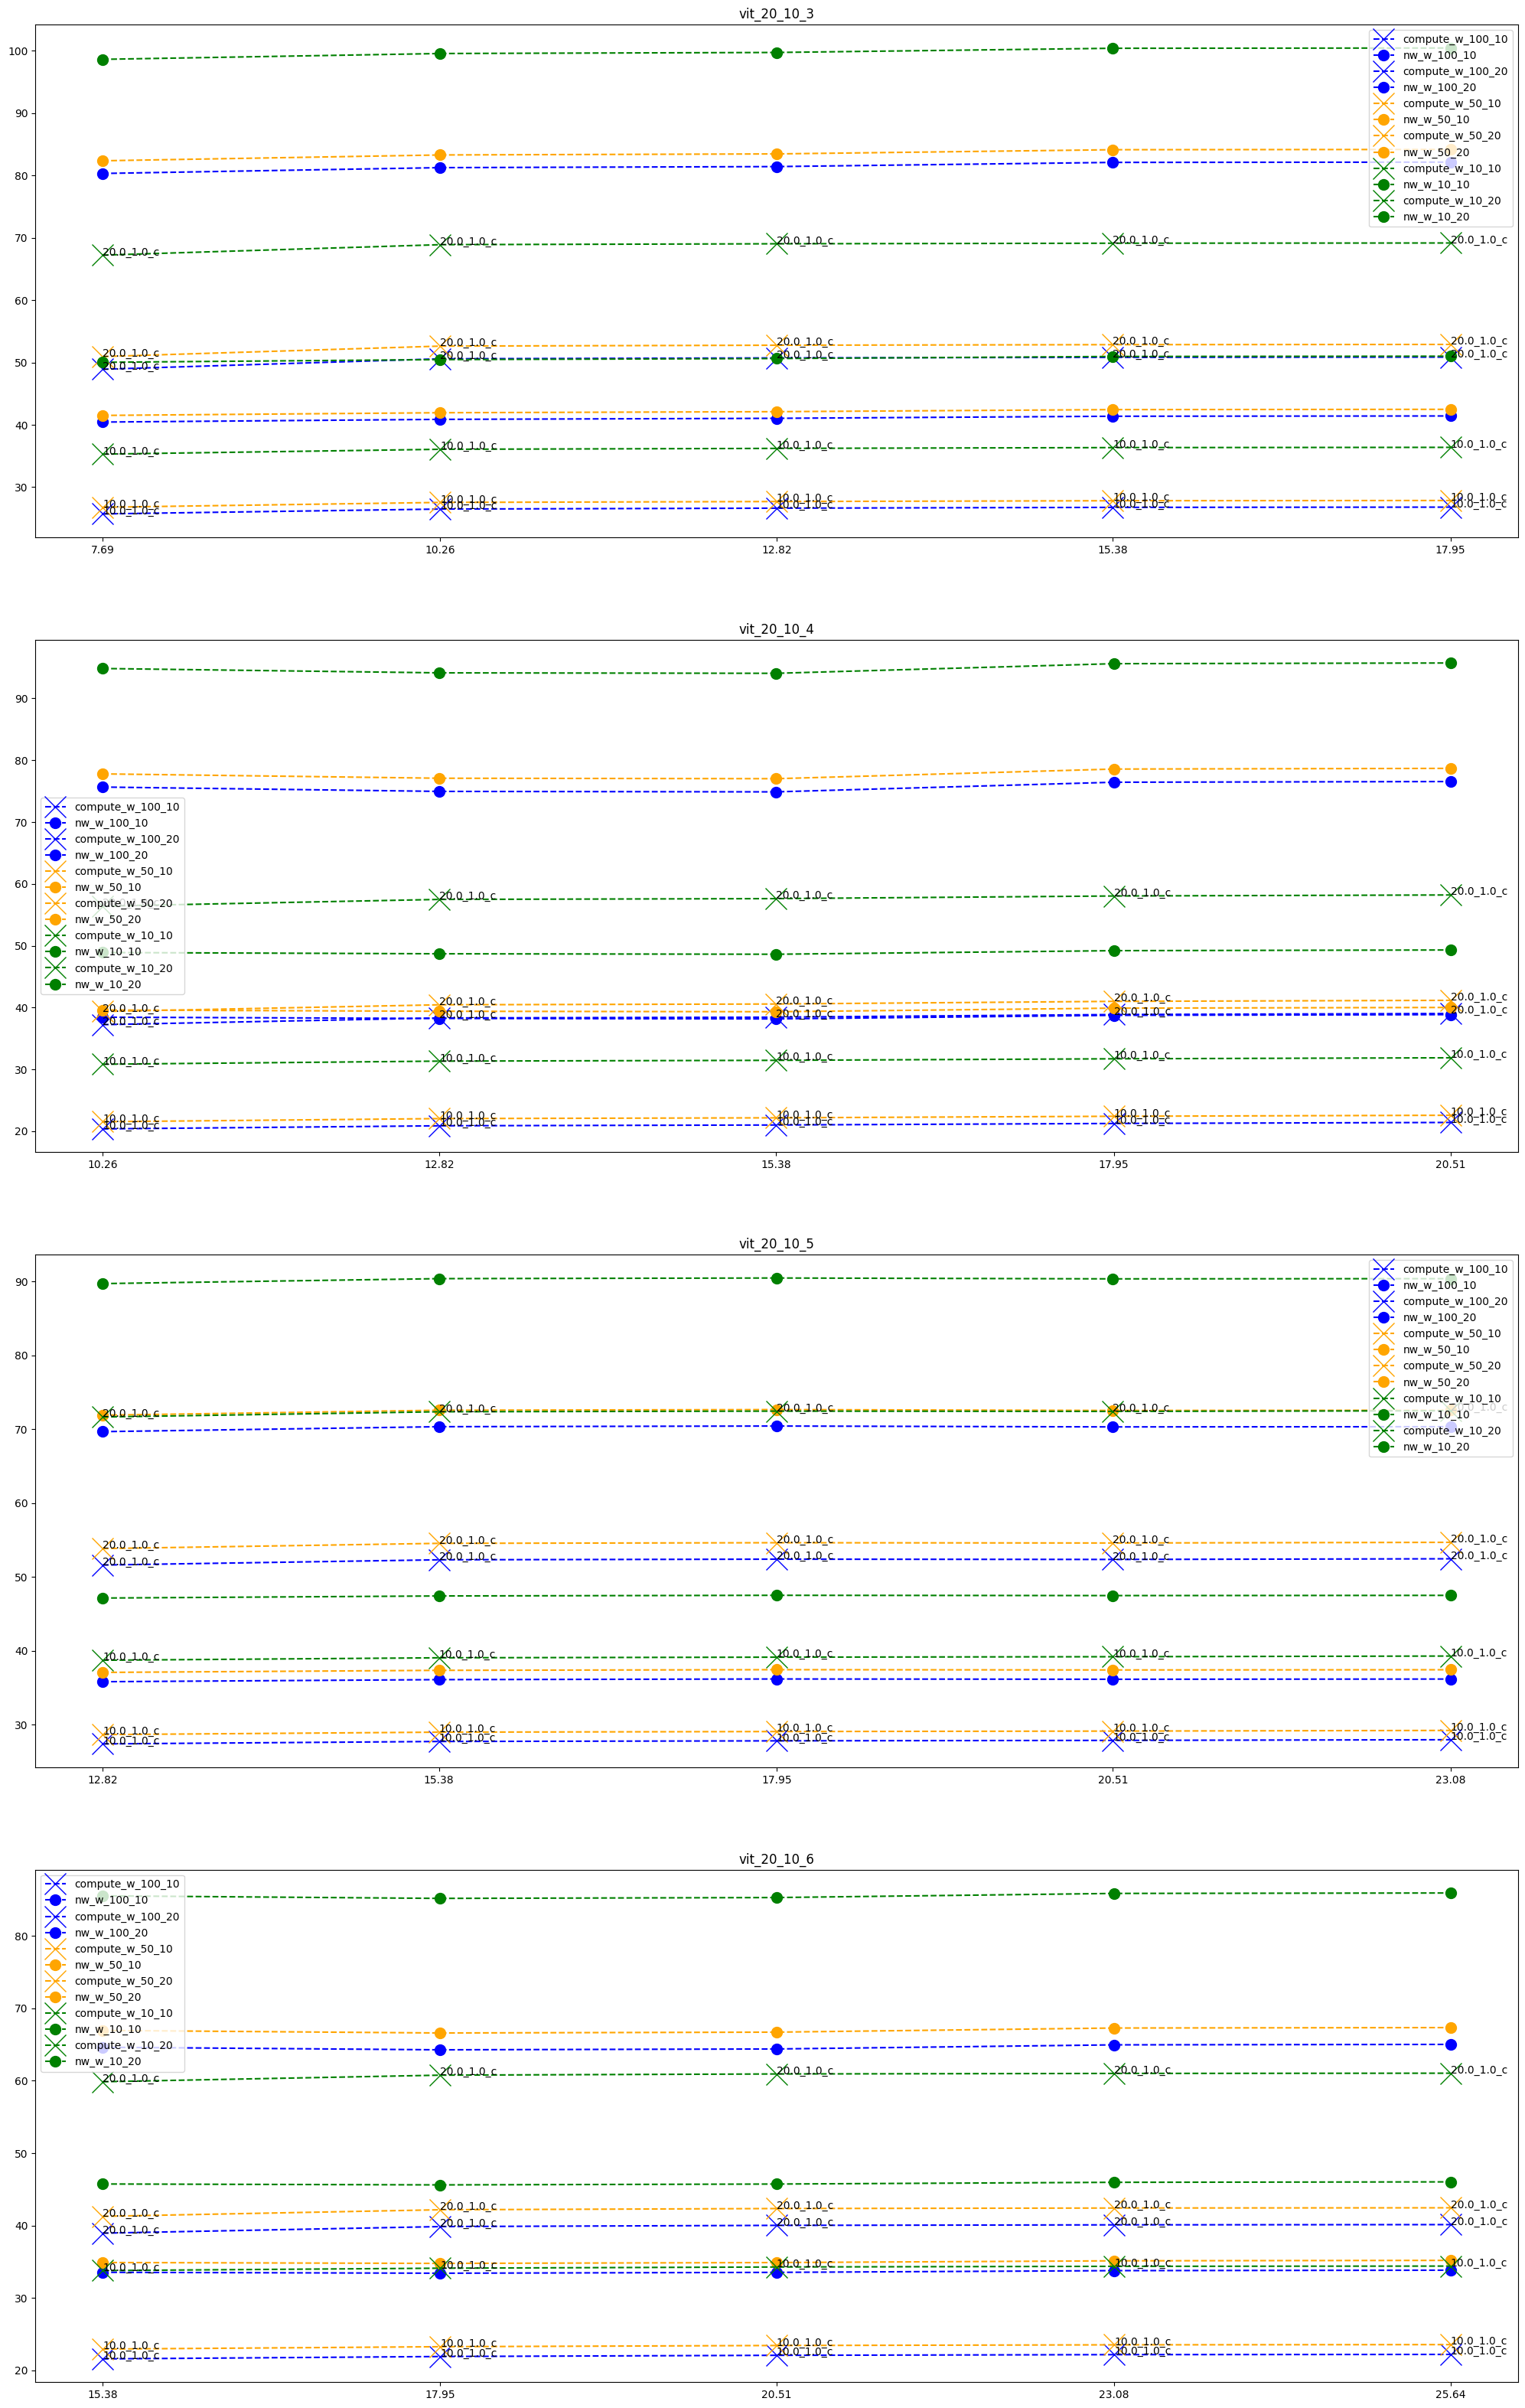

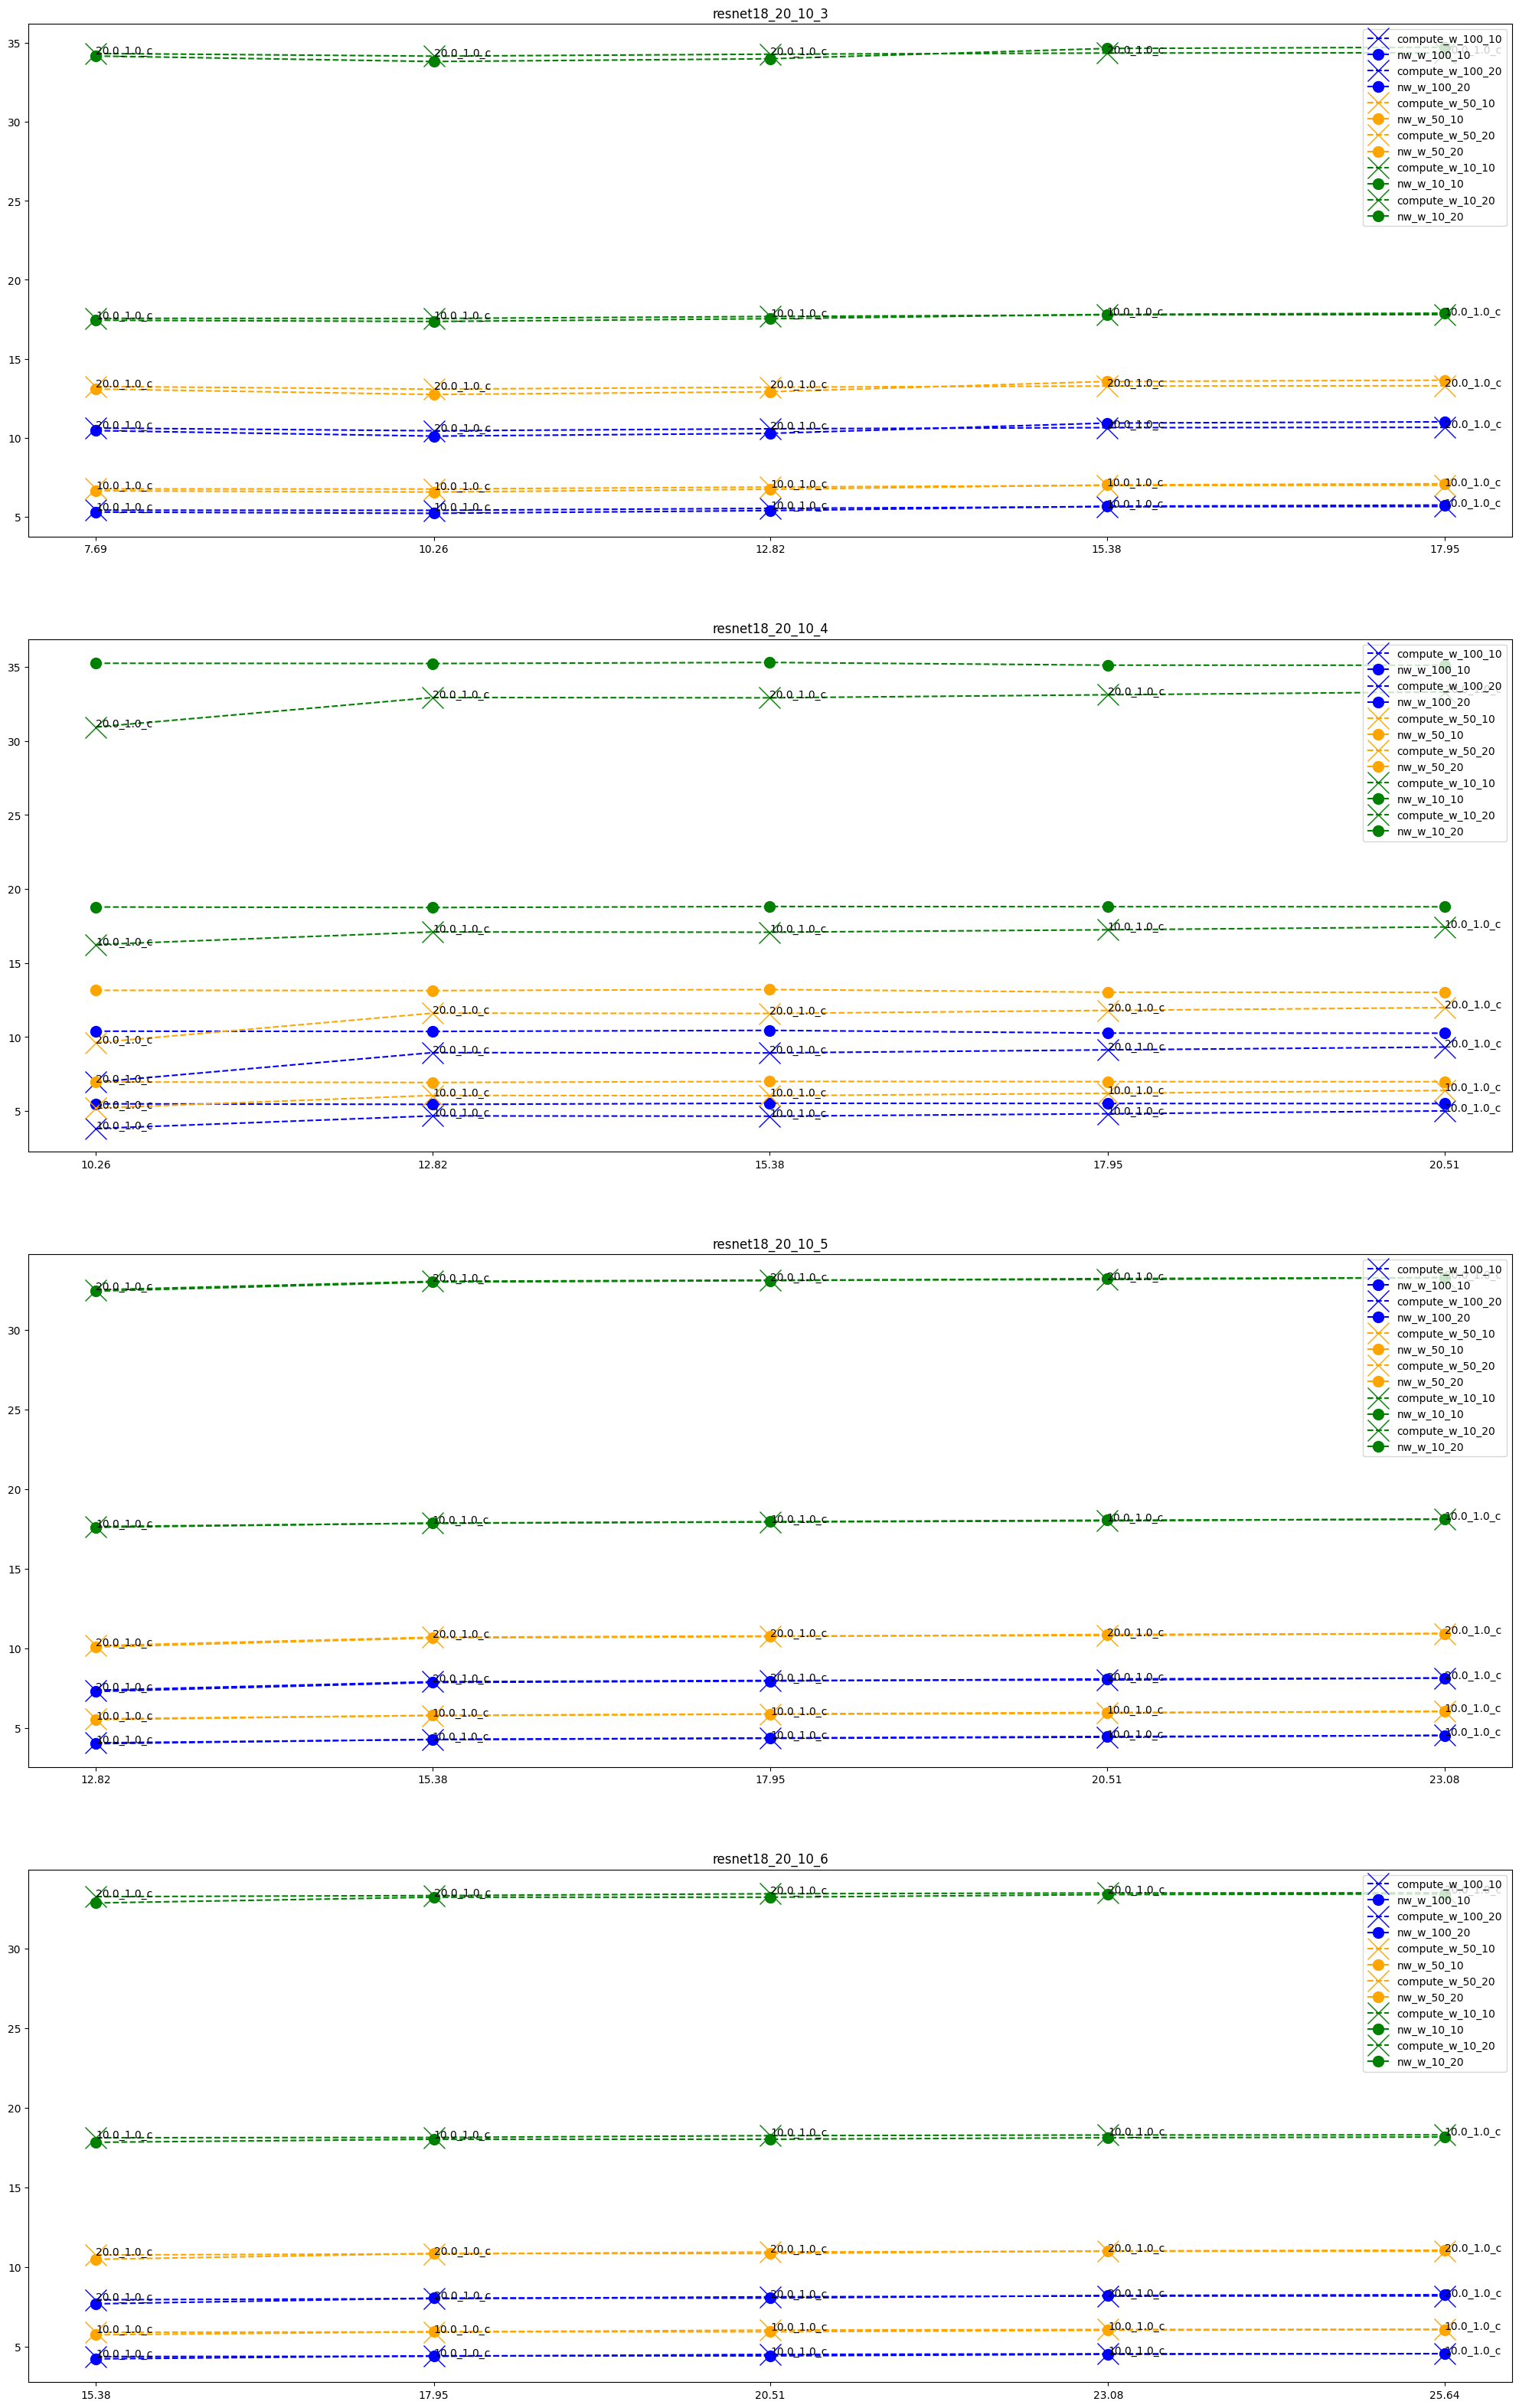

In [552]:
# fig, f_axs = plt.subplots( 3 , len(range(1,5)), figsize=(25,10))
f_axs = []
for i in range(3):
    fig, axs = plt.subplots(len(range(1,5)), figsize=(25,40))
    f_axs.append(axs)
bws=[100, 50, 10]
c_map=["blue", "orange", "green", "red", "black", "pink"]
for bw_ind, bw in enumerate(bws):    
# for bw in [240]:    
    # f=open(f"exploration.dict.{bw}", "r")
    f=open(f"exploration.dict.{bw}.mean", "r")
    real_maps, pred_maps = f.readlines()
    real_maps = literal_eval(real_maps.strip())
    pred_maps = literal_eval(pred_maps.strip())
    t_flag="all"
    for inp_ind, inp in enumerate(real_maps):
        if inp_ind>1:
            break
        for m_ind, model in enumerate(real_maps[inp]):
            axs=f_axs[m_ind]
            # fig, axs = plt.subplots(len(real_maps[inp][model].keys()), figsize=(25,10))

            for w_ind, world in enumerate(real_maps[inp][model]):

                if t_flag=="c" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][0][0] for bg in real_maps[inp][model][world]]
                    # y = [inp/i for i in y]
                    #bn_bs_c or nw
                    real_str = [f"{real_maps[inp][model][world][bg][0][1]}_{real_maps[inp][model][world][bg][0][2]}_{real_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][0][0] for bg in pred_maps[inp][model][world]]
                    # pred_y = [inp/p for p in pred_y]

                    pred_str = [f"{pred_maps[inp][model][world][bg][0][1]}_{pred_maps[inp][model][world][bg][0][2]}_{pred_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]
                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker="x", markersize=20, color=c_map[bw_ind], label=f"compute_w_{bw}_{inp}")
                    axs[w_ind].set_xticks(x)
                    for i in range(len(x)):
                        axs[w_ind].text(x[i],y[i],real_str[i])
                    
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse c {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae c {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape c {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()

                if t_flag=="nw" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][1][0] for bg in real_maps[inp][model][world]]
                    real_str = [f"{real_maps[inp][model][world][bg][1][1]}_{real_maps[inp][model][world][bg][1][2]}_{real_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][1][0] for bg in pred_maps[inp][model][world]]
                    pred_str = [f"{pred_maps[inp][model][world][bg][1][1]}_{pred_maps[inp][model][world][bg][1][2]}_{pred_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]

                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker=".", markersize=20, color=c_map[bw_ind], label=f"nw_w_{bw}_{inp}")
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],y[i],real_str[i])
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse nw {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae nw {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape nw {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()
                
                axs[w_ind].set_title(f"{model}_{inp}_{bw}_{world}")    
                axs[w_ind].legend()
        #     break
        # break


In [ ]:
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
